# Erdbeere Recipe Clustering - MDS + All Algorithms (v2 Without Threshold)

**Version:** v2 - no olfactory threshold used in feature vectors.
**Pipeline:** Remove ignore-list substances (CAS-based) -> normalise Totalmenge per recipe -> MDS clustering.
All feature vectors use **`use_threshold=False`** - quantities are compared by normalised relative proportion only.


## Algorithm Reference

| Algorithm | Type | How it works (short) |
|---|---|---|
| **k-Means** | Centroid partition | Iteratively assigns each recipe to the nearest centroid and recomputes centroids until convergence. Minimises total within-cluster variance (Euclidean). k is fixed. |
| **k-Medoids (PAM)** | Medoid partition | Like k-Means but centres are actual data points (*medoids*). More robust to outliers; operates on any distance matrix — here the precomputed cosine distance. |
| **Ward Linkage** | Hierarchical | Builds a merge tree (dendrogram) by always joining the pair of clusters whose merger causes the smallest increase in total within-cluster variance. A cut at distance *t* gives *k* clusters. |
| **DBSCAN** | Density-based | Groups recipes within distance ε of at least `min_samples` neighbours into a cluster. Points that never reach that density threshold become *noise* (resolved here to the nearest cluster). *k* is data-driven. |
| **HDBSCAN** | Hierarchical density | Builds a full hierarchy of DBSCAN solutions across all ε values and extracts the most stable clusters. More robust than DBSCAN when cluster densities vary. |
| **GMM** | Probabilistic | Models data as a mixture of *k* multivariate Gaussians. Each recipe has a soft probability of belonging to each component; the hard label is the highest-probability component. |
| **Spectral Clustering** | Graph-based | Builds a similarity graph (cosine similarity as affinity), computes the Laplacian eigenvectors, then applies k-Means in that low-dimensional embedding. Finds non-convex clusters invisible to k-Means. |
| **Fuzzy c-Means** | Soft partition | Each recipe belongs to *all* k clusters simultaneously with a membership degree (degrees sum to 1). Minimises a weighted within-cluster distance; the fuzziness exponent *m* controls how soft the boundaries are. Hard labels are derived by argmax. |
| **SOM** | Topological map | Trains a 2-D node grid on the recipe vectors via competitive learning: the winning node and its neighbours update towards each input. Recipes are assigned to their closest node; node groups are mapped to *k* clusters via k-Means on the node weights. |
| **DEC (simplified)** | Deep / embedding | Encodes recipes into a compact space (PCA here; a neural autoencoder in the full method), initialises centres with k-Means, then iteratively sharpens soft assignments using a Student-*t* kernel and a KL-divergence target distribution (Xie et al., ICML 2016). |

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    from sklearn.cluster import HDBSCAN as _HDBSCAN
    _has_hdbscan = True
except ImportError:
    _has_hdbscan = False

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLUSTER_COLORS = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
    '#F4A261', '#A8DADC', '#6A0572', '#264653',
]

# ── Data paths ────────────────────────────────────────────────────────────────
CSV_PATH    = Path('../data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv')
IGNORE_PATH = Path('../data/gold/ignone_substances.csv')

# ── Erdbeere column names ─────────────────────────────────────────────────────
OT1           = 'Odour-Type 1'
OT2           = 'Odour-Type 2'
OT3           = 'Odour-Type 3'
THRESHOLD_COL = 'Threshold'
REZ_COL       = 'Rez.-Nr.'
IDENT_COL     = 'Ident'
CAS_COL       = 'CAS-Nr.'
NAME_COL      = 'Name'
TOTAL_COL     = 'Totalmenge'

print('Libraries loaded.')
print(f'HDBSCAN available: {_has_hdbscan}')

Libraries loaded.
HDBSCAN available: True


## 1. Load Erdbeere Recipe Data

In [2]:
def to_float(v, fallback=0.0):
    # Parse European decimal strings ('1,3E-5') and native floats/ints
    if v is None: return fallback
    if isinstance(v, (int, float)): return float(v)
    try: return float(str(v).strip().replace(",", "."))
    except: return fallback

# -- Load CSV ------------------------------------------------------------------
df_raw = pd.read_csv(CSV_PATH, dtype=str)
df_raw[TOTAL_COL]     = df_raw[TOTAL_COL].apply(to_float)
df_raw[THRESHOLD_COL] = df_raw[THRESHOLD_COL].apply(to_float)
df = df_raw[df_raw[REZ_COL].notna()].copy()

# -- Ignore list: CAS-based masking -------------------------------------------
# Match by Ident or Name first, then zero ALL rows sharing the same CAS number
# (catches alternate Idents of the same substance, e.g. Triethylcitrat variants)
if IGNORE_PATH.exists():
    ign             = pd.read_csv(IGNORE_PATH)
    ign_idents      = set(ign[IDENT_COL].dropna().astype(str).str.strip())
    names_to_ignore = {str(n).lower().strip() for n in ign[NAME_COL]}
    mask = (
        df[IDENT_COL].astype(str).str.strip().isin(ign_idents) |
        df[NAME_COL].str.lower().str.strip().isin(names_to_ignore)
    )
    cas_to_ignore = set(df.loc[mask, CAS_COL].dropna().astype(str).str.strip())
    df.loc[df[CAS_COL].astype(str).str.strip().isin(cas_to_ignore), TOTAL_COL] = 0.0
    print(f"Ignored idents: {len(ign_idents)} | Ignored CAS: {len(cas_to_ignore)}")
else:
    print("No ignore list found -- all ingredients included.")

# -- Normalize Totalmenge per recipe (relative proportions) -------------------
per_recipe_total = df.groupby(REZ_COL)[TOTAL_COL].transform("sum")
df[TOTAL_COL] = np.where(per_recipe_total > 0,
                          df[TOTAL_COL] / per_recipe_total,
                          df[TOTAL_COL])

recipes = df[REZ_COL].unique().tolist()
print(f"Recipes           : {len(recipes)}")
print(f"Ingredients (rows) : {len(df)}")
print(f"Sample recipes    : {recipes[:6]}")
print(f"Odour types present: OT1={df[OT1].notna().sum()} rows, "
      f"OT2={df[OT2].notna().sum()}, OT3={df[OT3].notna().sum()}")
n = len(recipes)


Ignored idents: 10 | Ignored CAS: 6
Recipes           : 130
Ingredients (rows) : 3366
Sample recipes    : ['188.977', '187.004P', '186.293P', '185.046', '187.015P', '185.028']
Odour types present: OT1=3366 rows, OT2=3120, OT3=1540


## 2. Feature & MDS Helpers

In [3]:
def pos_weight(position, n_cols):
    return (n_cols + 1 - position) / n_cols

def thresh_factor(threshold_ppm, fallback=1.0):
    try:
        raw = str(threshold_ppm).strip().replace(',', '.')
        t = float(raw)
        return 1.0 / t if (not np.isnan(t) and t > 0) else fallback
    except (TypeError, ValueError):
        return fallback

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocabulary(df, feature_cols):
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t: all_terms.add(t)
    return sorted(all_terms)

def build_recipe_vectors(df, recipes, feature_cols_weighted, use_threshold):
    feature_cols = [col for col, _ in feature_cols_weighted]
    vocab        = build_vocabulary(df, feature_cols)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors      = np.zeros((len(recipes), len(vocab)), dtype=np.float64)
    for r_idx, recipe in enumerate(recipes):
        for _, row in df[df[REZ_COL] == recipe].iterrows():
            qty = float(row[TOTAL_COL])
            if qty <= 0: continue
            t_fac    = thresh_factor(row[THRESHOLD_COL]) if use_threshold else 1.0
            ingr_base = qty * t_fac
            for col, col_weight in feature_cols_weighted:
                term = norm_term(row.get(col))
                if term and term in vocab_to_idx:
                    vectors[r_idx, vocab_to_idx[term]] += col_weight * ingr_base
    return vocab, normalize(vectors)

def cosine_dissimilarity(vecs):
    sim = np.clip(vecs @ vecs.T, -1.0, 1.0)
    diss = 1.0 - sim
    np.fill_diagonal(diss, 0.0)
    return diss

def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    if len(x) < 2:
        ax.scatter(x, y, s=80, color=kwargs.get('facecolor', 'gray'), zorder=4)
        return
    cov = np.cov(x, y)
    ev, evec = np.linalg.eigh(cov)
    order = ev.argsort()[::-1]
    ev, evec = ev[order], evec[:, order]
    angle  = np.degrees(np.arctan2(*evec[:, 0][::-1]))
    width  = max(2 * n_std * np.sqrt(abs(ev[0])), 0.001)
    height = max(2 * n_std * np.sqrt(abs(ev[1])), 0.001)
    ax.add_patch(Ellipse(xy=(np.mean(x), np.mean(y)),
                         width=width, height=height, angle=angle, **kwargs))

def mds_plot(ax, coords, names, cluster_labels, title, show_legend=False):
    unique_clusters = sorted(np.unique(cluster_labels))
    colors = CLUSTER_COLORS[:len(unique_clusters)]
    color_map = {c: colors[i % len(colors)] for i, c in enumerate(unique_clusters)}
    ax.set_facecolor('#FAFAFA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
    ax.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)
    for cid in unique_clusters:
        mask = cluster_labels == cid
        cx, cy = coords[mask, 0], coords[mask, 1]
        col = color_map[cid]
        confidence_ellipse(cx, cy, ax, n_std=1.5,
                           facecolor=col, alpha=0.15, edgecolor=col,
                           linewidth=1.3, linestyle='--', zorder=2)
        ax.scatter(cx, cy, color=col, s=60, zorder=4, edgecolors='white', lw=0.7)
        for i, name in enumerate(np.array(names)[mask]):
            ax.annotate(name, (cx[i], cy[i]), fontsize=6.5, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color=col)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('MDS Dim 1', fontsize=8)
    ax.set_ylabel('MDS Dim 2', fontsize=8)
    ax.grid(True, alpha=0.2, lw=0.4)
    ax.tick_params(labelsize=7)
    if show_legend:
        patches = [mpatches.Patch(color=color_map[c], label=f'C{c}') for c in unique_clusters]
        ax.legend(handles=patches, fontsize=7, loc='best', framealpha=0.8)

def run_mds(diss, n_clusters=None, threshold=None):
    mds = MDS(n_components=2, dissimilarity='precomputed', metric=True,
              n_init=10, max_iter=1000, random_state=42, normalized_stress='auto')
    coords = mds.fit_transform(diss)
    Z = linkage(squareform(diss, checks=False), method='ward')
    if n_clusters is not None:
        labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    elif threshold is not None:
        labels = fcluster(Z, t=threshold, criterion='distance')
    else:
        labels = fcluster(Z, t=0.25, criterion='distance')
    return coords, Z, labels, mds.stress_

print('Helpers defined.')


Helpers defined.


## 3. Auto-detect Optimal Number of Clusters

Since no panelist free-sorting is available yet, we let the data decide.
Four complementary methods are used on the **M1 feature space** (OT1 weighted by normalised Totalmenge, **no threshold**):

| Method | Optimum |
|---|---|
| Ward dendrogram | Largest gap between merges |
| Silhouette score | Maximise |
| Davies-Bouldin index | Minimise |
| Calinski-Harabasz score | Maximise |


In [4]:
# Build M1 vectors (OT1, no threshold) — used as the reference for cluster detection
_, vecs_m2 = build_recipe_vectors(df, recipes, [(OT1, 1.0)], use_threshold=False)
diss_m2    = cosine_dissimilarity(vecs_m2)
coords_m2, Z_m2, _, stress_m2 = run_mds(diss_m2, threshold=0.25)

n = len(recipes)
k_range = range(2, min(n - 1, 9))  # k = 2..8 (or n-2)

# Ward dendrogram: find the k most natural clusters by looking at merge heights
Z_m2_sq = linkage(squareform(diss_m2, checks=False), method='ward')
merge_heights = Z_m2_sq[:, 2]
height_gaps   = np.diff(merge_heights[::-1])  # largest gap = most natural cut
best_k_ward   = int(np.argmax(height_gaps) + 2)  # +2 because diff shrinks by 1

# Silhouette, DB, CH over k range
sil_scores, db_scores, ch_scores = [], [], []
for k in k_range:
    lbl = fcluster(Z_m2_sq, t=k, criterion='maxclust')
    # Need at least 2 clusters and at least 1 sample per cluster
    if len(np.unique(lbl)) < 2:
        sil_scores.append(-1); db_scores.append(9999); ch_scores.append(0)
        continue
    sil_scores.append(silhouette_score(diss_m2, lbl, metric='precomputed'))
    db_scores.append(davies_bouldin_score(vecs_m2, lbl))
    ch_scores.append(calinski_harabasz_score(vecs_m2, lbl))

best_k_sil = int(list(k_range)[int(np.argmax(sil_scores))])
best_k_db  = int(list(k_range)[int(np.argmin(db_scores))])
best_k_ch  = int(list(k_range)[int(np.argmax(ch_scores))])

votes = [best_k_ward, best_k_sil, best_k_db, best_k_ch]
from collections import Counter
vote_counts = Counter(votes)
OPTIMAL_K = vote_counts.most_common(1)[0][0]

print(f'Ward dendrogram best k : {best_k_ward}')
print(f'Silhouette best k      : {best_k_sil}  (score={max(sil_scores):.3f})')
print(f'Davies-Bouldin best k  : {best_k_db}   (score={min(db_scores):.3f})')
print(f'Calinski-Harabasz best k: {best_k_ch}  (score={max(ch_scores):.1f})')
print(f'\n→ OPTIMAL_K (majority vote) = {OPTIMAL_K}')
print(f'MDS stress (M1, Ward) = {stress_m2:.3f}')


Ward dendrogram best k : 128
Silhouette best k      : 2  (score=0.653)
Davies-Bouldin best k  : 2   (score=0.784)
Calinski-Harabasz best k: 2  (score=134.6)

→ OPTIMAL_K (majority vote) = 2
MDS stress (M1, Ward) = 61.240


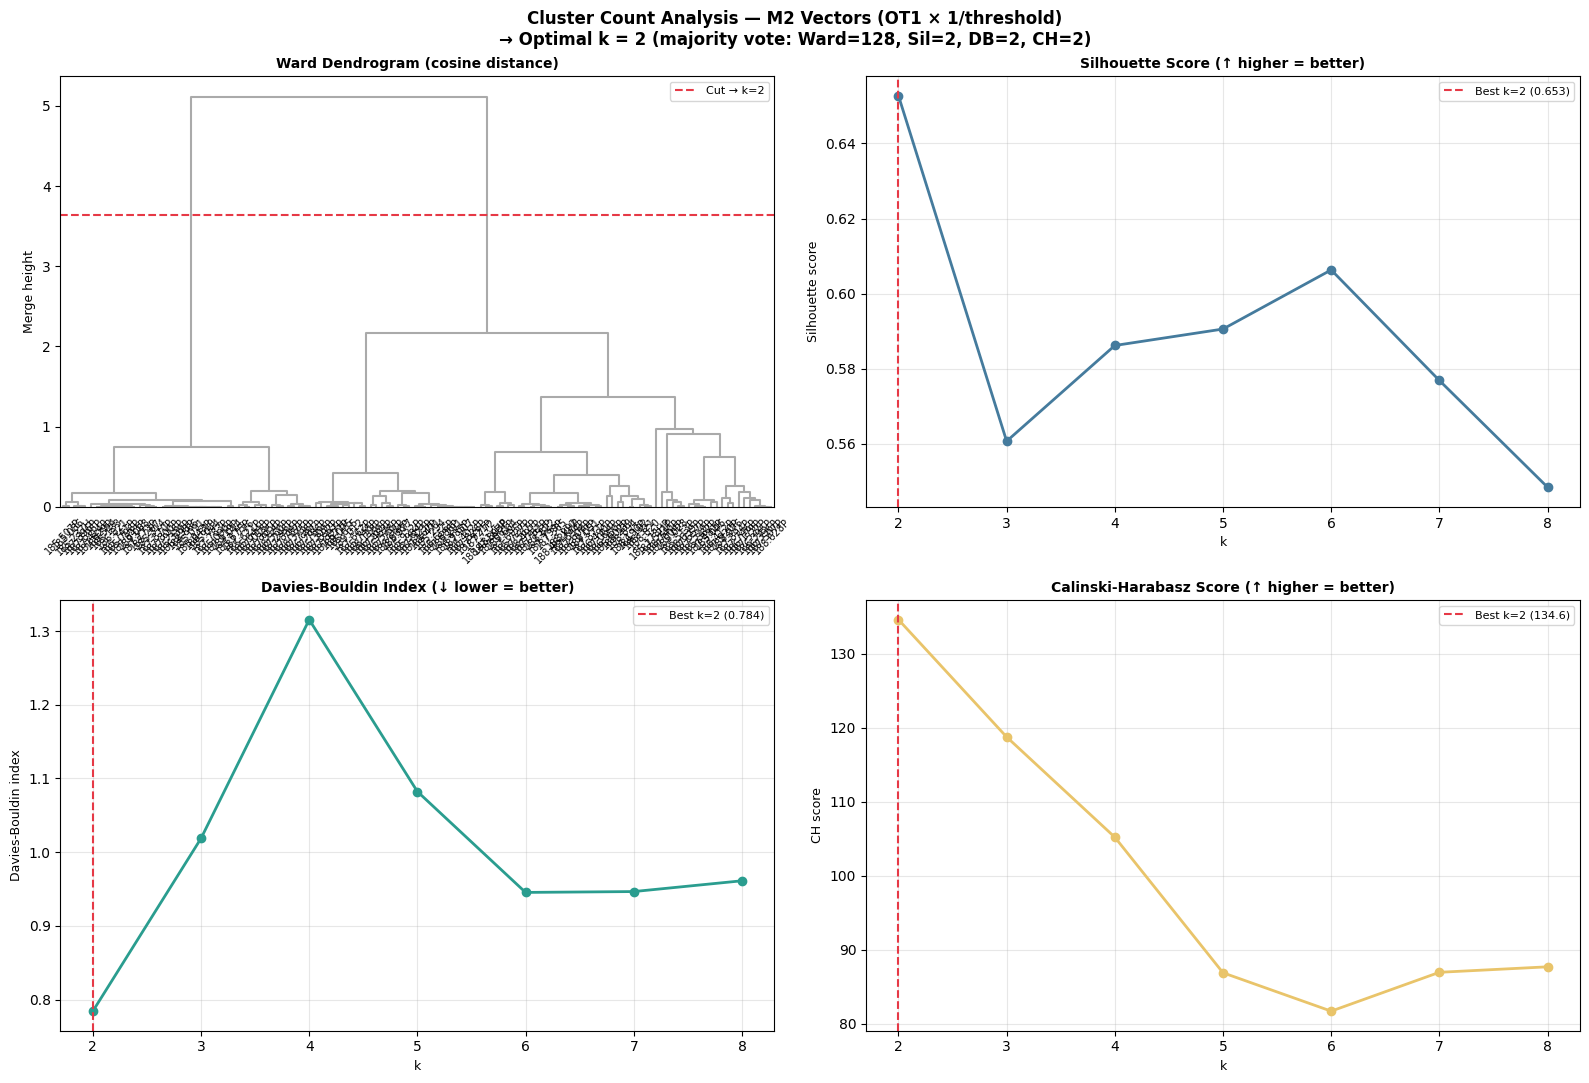

Saved. Final OPTIMAL_K = 2


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Dendrogram ───────────────────────────────────────────────────────────────
ax0 = axes[0, 0]
dendrogram(Z_m2_sq, labels=recipes, ax=ax0, leaf_rotation=45,
           leaf_font_size=7.5, color_threshold=0, above_threshold_color='#AAAAAA')
# Draw cut line for OPTIMAL_K
cut_height = 0.5 * (Z_m2_sq[-(OPTIMAL_K - 1), 2] + Z_m2_sq[-(OPTIMAL_K), 2])
ax0.axhline(cut_height, color='#E63946', lw=1.5, linestyle='--',
            label=f'Cut → k={OPTIMAL_K}')
ax0.set_title('Ward Dendrogram (cosine distance)', fontsize=10, fontweight='bold')
ax0.set_ylabel('Merge height', fontsize=9)
ax0.legend(fontsize=8)
ax0.tick_params(axis='x', labelsize=7)

# ── Silhouette ────────────────────────────────────────────────────────────────
ax1 = axes[0, 1]
ax1.plot(list(k_range), sil_scores, 'o-', color='#457B9D', lw=2)
ax1.axvline(best_k_sil, color='#E63946', lw=1.5, linestyle='--',
            label=f'Best k={best_k_sil} ({max(sil_scores):.3f})')
ax1.set_xlabel('k', fontsize=9); ax1.set_ylabel('Silhouette score', fontsize=9)
ax1.set_title('Silhouette Score (↑ higher = better)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Davies-Bouldin ────────────────────────────────────────────────────────────
ax2 = axes[1, 0]
ax2.plot(list(k_range), db_scores, 'o-', color='#2A9D8F', lw=2)
ax2.axvline(best_k_db, color='#E63946', lw=1.5, linestyle='--',
            label=f'Best k={best_k_db} ({min(db_scores):.3f})')
ax2.set_xlabel('k', fontsize=9); ax2.set_ylabel('Davies-Bouldin index', fontsize=9)
ax2.set_title('Davies-Bouldin Index (↓ lower = better)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Calinski-Harabasz ────────────────────────────────────────────────────────
ax3 = axes[1, 1]
ax3.plot(list(k_range), ch_scores, 'o-', color='#E9C46A', lw=2)
ax3.axvline(best_k_ch, color='#E63946', lw=1.5, linestyle='--',
            label=f'Best k={best_k_ch} ({max(ch_scores):.1f})')
ax3.set_xlabel('k', fontsize=9); ax3.set_ylabel('CH score', fontsize=9)
ax3.set_title('Calinski-Harabasz Score (↑ higher = better)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

fig.suptitle(f'Cluster Count Analysis — M2 Vectors (OT1 × 1/threshold)\n'
             f'→ Optimal k = {OPTIMAL_K} (majority vote: Ward={best_k_ward}, '
             f'Sil={best_k_sil}, DB={best_k_db}, CH={best_k_ch})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/erdbeere_cluster_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved. Final OPTIMAL_K = {OPTIMAL_K}')


## 4. All Models - MDS Maps at Optimal k

Two models are compared - both without threshold:

| Model | Features | Threshold |
|-------|----------|-----------|
| M1: OT1 | OT1 weighted by normalised Totalmenge | None |
| M2: OT1+OT2+OT3 | Three OTs weighted by position | None |


M1: OT1                                   stress=61.240  2 clusters
M2: OT1+OT2+OT3                           stress=39.000  2 clusters


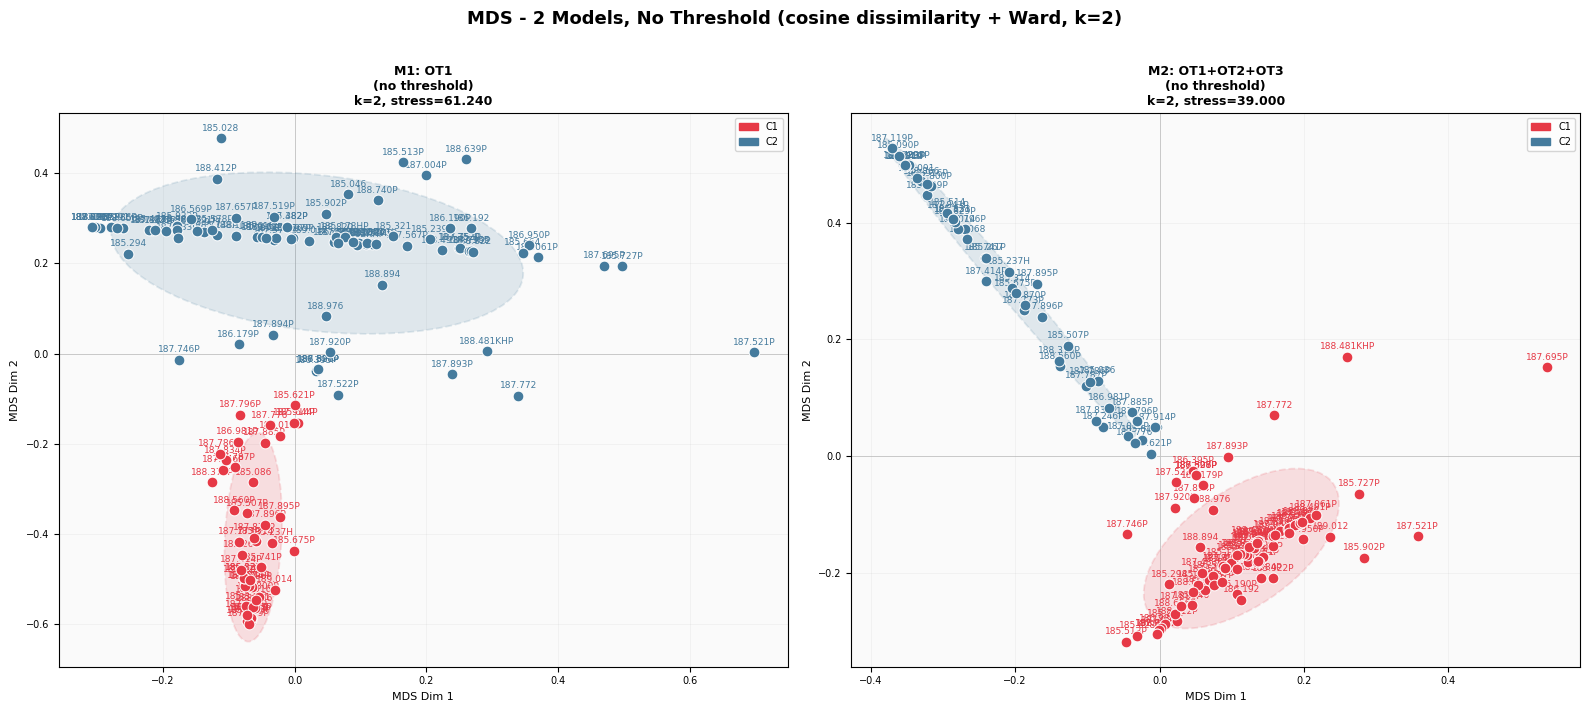

Saved.


In [6]:
MODEL_CONFIGS = [
    {"name": "M1: OT1\n(no threshold)",
     "fcw": [(OT1, 1.0)],
     "use_thresh": False},
    {"name": "M2: OT1+OT2+OT3\n(no threshold)",
     "fcw": [(OT1, pos_weight(1, 4)), (OT2, pos_weight(2, 4)), (OT3, pos_weight(3, 4))],
     "use_thresh": False},
]

all_model_results = []
for cfg in MODEL_CONFIGS:
    _, vecs = build_recipe_vectors(df, recipes, cfg["fcw"], cfg["use_thresh"])
    diss    = cosine_dissimilarity(vecs)
    coords, Z, labels, stress = run_mds(diss, n_clusters=OPTIMAL_K)
    all_model_results.append({
        "name": cfg["name"], "coords": coords, "labels": labels,
        "stress": stress, "n_clusters": len(np.unique(labels))
    })
    print(f"{cfg['name'].split(chr(10))[0]:40s}  stress={stress:.3f}  "
          f"{len(np.unique(labels))} clusters")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, res in zip(axes.flatten(), all_model_results):
    mds_plot(ax, res["coords"], recipes, res["labels"],
             f"{res['name']}\nk={OPTIMAL_K}, stress={res['stress']:.3f}",
             show_legend=True)
fig.suptitle(f"MDS - 2 Models, No Threshold (cosine dissimilarity + Ward, k={OPTIMAL_K})",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/erdbeere_v2_mds_2models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")


## 5. Multi-Algorithm Comparison at Optimal k

All 10 algorithms are applied to the **M1 recipe vectors** (OT1, normalised Totalmenge, no threshold) with `k = OPTIMAL_K`.
DBSCAN and HDBSCAN are density-based and may find a different natural k; their parameters are scanned to best approximate `OPTIMAL_K`, and residual noise points are resolved to the nearest cluster.

| Algorithm | Type |
|---|---|
| k-Means | Centroid partition |
| k-Medoids (PAM) | Medoid partition on cosine distance |
| Ward Linkage | Hierarchical (baseline) |
| DBSCAN | Density-based |
| HDBSCAN | Hierarchical density |
| GMM | Probabilistic (PCA pre-reduction) |
| Spectral Clustering | Graph-based (cosine affinity) |
| Fuzzy c-Means | Soft partition (PCA pre-reduction) |
| SOM | Topological 2D map |
| DEC (simplified) | PCA encoding + Student-t refinement |


In [7]:
# ── k-Medoids (PAM) ──────────────────────────────────────────────────────────
def kmedoids(dist_matrix, k, max_iter=500, random_state=42):
    n = dist_matrix.shape[0]
    rng = np.random.RandomState(random_state)
    medoids = list(rng.choice(n, k, replace=False))
    for _ in range(max_iter):
        labels = np.argmin(dist_matrix[:, medoids], axis=1)
        new_medoids = []
        for c in range(k):
            pts = np.where(labels == c)[0]
            if len(pts) == 0: new_medoids.append(medoids[c]); continue
            sub = dist_matrix[np.ix_(pts, pts)]
            new_medoids.append(int(pts[np.argmin(sub.sum(axis=1))]))
        if new_medoids == medoids: break
        medoids = new_medoids
    return np.argmin(dist_matrix[:, medoids], axis=1) + 1

# ── Resolve DBSCAN/HDBSCAN noise to nearest non-noise point ──────────────────
def resolve_noise(raw, dist_matrix):
    labels = raw.copy()
    noise  = np.where(labels == -1)[0]
    if len(noise) == 0: return labels + 1
    non_noise = np.where(labels != -1)[0]
    if len(non_noise) == 0: return np.ones(len(labels), dtype=int)
    for i in noise:
        labels[i] = labels[non_noise[np.argmin(dist_matrix[i, non_noise])]]
    return labels + 1

# ── Fuzzy c-Means (Bezdek 1984) ───────────────────────────────────────────────
def fuzzy_cmeans(X, c, m=2.0, max_iter=500, tol=1e-7, random_state=42):
    rng = np.random.RandomState(random_state)
    n   = X.shape[0]
    U   = rng.dirichlet(np.ones(c), n).T
    for _ in range(max_iter):
        Um        = U ** m
        centroids = (Um @ X) / Um.sum(axis=1, keepdims=True)
        dist      = np.array([[np.linalg.norm(X[j] - centroids[i]) for j in range(n)] for i in range(c)])
        dist      = np.maximum(dist, 1e-12)
        ratio     = dist[None, :, :] / dist[:, None, :]
        U_new     = 1.0 / (ratio ** (2.0 / (m - 1))).sum(axis=1)
        U_new    /= U_new.sum(axis=0, keepdims=True)
        if np.max(np.abs(U_new - U)) < tol: break
        U = U_new
    return np.argmax(U, axis=0) + 1

# ── SOM (square grid of ⌈√k⌉² nodes, reassigned to k via k-Means) ────────────
def som_cluster(X, k, lr=0.5, sigma=1.5, n_iter=10000, random_state=42):
    from sklearn.preprocessing import normalize as _norm
    rng    = np.random.RandomState(random_state)
    g      = int(np.ceil(np.sqrt(k)))   # grid side length (g×g ≥ k nodes)
    n_nodes = g * g
    weights = _norm(rng.randn(n_nodes, X.shape[1]))
    node_pos = np.array([(r, c) for r in range(g) for c in range(g)], dtype=float)
    for t in range(n_iter):
        frac   = 1.0 - t / n_iter
        lr_t   = lr * frac
        sig_t  = max(sigma * frac, 0.01)
        xi     = X[rng.randint(0, X.shape[0])]
        bmu    = np.argmin(np.linalg.norm(weights - xi, axis=1))
        d2     = ((node_pos - node_pos[bmu]) ** 2).sum(axis=1)
        h      = np.exp(-d2 / (2 * sig_t ** 2))
        weights += lr_t * h[:, None] * (xi - weights)
    # Map node activations → k clusters via k-Means on node weights
    node_labels = KMeans(n_clusters=k, n_init=30, random_state=random_state).fit_predict(weights)
    recipe_labels = np.array([node_labels[np.argmin(np.linalg.norm(weights - xi, axis=1))]
                               for xi in X])
    return recipe_labels + 1

# ── DEC simplified: PCA encoding + Student-t iterative refinement ─────────────
def dec_simplified(X, n_clusters, enc_dim=8, n_iter=300, random_state=42):
    d   = min(enc_dim, X.shape[1], X.shape[0] - 1)
    Z   = PCA(n_components=d, random_state=random_state).fit_transform(X)
    centers = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state).fit(Z).cluster_centers_.copy()
    for _ in range(n_iter):
        dist2 = np.sum((Z[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        q     = 1.0 / (1.0 + dist2)
        q    /= q.sum(axis=1, keepdims=True)
        f     = q.sum(axis=0)
        p     = (q ** 2) / np.maximum(f, 1e-12)
        p    /= p.sum(axis=1, keepdims=True)
        for j in range(n_clusters):
            centers[j] = (p[:, j:j+1] * Z).sum(axis=0) / max(p[:, j].sum(), 1e-12)
    return np.argmax(q, axis=1) + 1

print('Custom algorithm implementations ready.')


Custom algorithm implementations ready.


In [8]:
print(f'DBSCAN eps scan targeting k={OPTIMAL_K} (precomputed cosine distance):')
print(f'  {"eps":>6}  clusters  noise_pts')
best_db_eps, best_db_raw = None, None

for eps in np.arange(0.01, 1.00, 0.01):
    raw    = DBSCAN(eps=eps, min_samples=2, metric='precomputed').fit_predict(diss_m2)
    n_clust = len(set(raw) - {-1})
    n_noise = (raw == -1).sum()
    marker  = f'  ← {OPTIMAL_K} clusters, {n_noise} noise' if n_clust == OPTIMAL_K else ''
    if n_clust > 0:
        print(f'  {eps:6.2f}  {n_clust:8d}  {n_noise:9d}{marker}')
    if best_db_eps is None or abs(n_clust - OPTIMAL_K) < abs(len(set(best_db_raw) - {-1}) - OPTIMAL_K):
        best_db_eps, best_db_raw = eps, raw
    if n_clust == OPTIMAL_K and n_noise == 0:
        best_db_eps, best_db_raw = eps, raw; break

labels_dbscan  = resolve_noise(best_db_raw, diss_m2)
n_clust_db     = len(set(best_db_raw) - {-1})
n_noise_db     = (best_db_raw == -1).sum()
print(f'\nSelected eps={best_db_eps:.2f} → {n_clust_db} clusters, {n_noise_db} noise pts resolved')
print(f'Final DBSCAN counts: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}')


DBSCAN eps scan targeting k=2 (precomputed cosine distance):
     eps  clusters  noise_pts
    0.01        18         50
    0.02        10         25
    0.03         6         16
    0.04         5         14
    0.05         6         10
    0.06         4          7
    0.07         1          5
    0.08         1          5
    0.09         1          4
    0.10         1          4
    0.11         1          4
    0.12         1          2
    0.13         1          1
    0.14         1          1
    0.15         1          1
    0.16         1          1
    0.17         1          1
    0.18         1          1
    0.19         1          1
    0.20         1          1
    0.21         1          1
    0.22         1          1
    0.23         1          1
    0.24         1          1
    0.25         1          1
    0.26         1          1
    0.27         1          1
    0.28         1          1
    0.29         1          1
    0.30         1          1
    0.31 

In [9]:
K = OPTIMAL_K  # shorthand

# ── HDBSCAN ──────────────────────────────────────────────────────────────────
if _has_hdbscan:
    print(f'HDBSCAN scan targeting k={K}:')
    best_hdb_mcs, best_hdb_raw = None, None
    for mcs in range(2, n + 1):
        raw    = _HDBSCAN(min_cluster_size=mcs, metric='precomputed').fit_predict(diss_m2)
        n_clust = len(set(raw) - {-1})
        n_noise = (raw == -1).sum()
        print(f'  min_cluster_size={mcs:2d}  →  {n_clust} clusters, {n_noise} noise pts')
        if best_hdb_mcs is None or abs(n_clust - K) < abs(len(set(best_hdb_raw) - {-1}) - K):
            best_hdb_mcs, best_hdb_raw = mcs, raw
    labels_hdbscan = resolve_noise(best_hdb_raw, diss_m2)
    print(f'Selected min_cluster_size={best_hdb_mcs} → {len(set(best_hdb_raw)-{-1})} clusters')
else:
    labels_hdbscan = None
    print('HDBSCAN skipped (sklearn < 1.3)')

# -- Ward (M1 reference, no threshold) -- already computed via auto-detected k --
_, vecs_m2 = build_recipe_vectors(df, recipes, [(OT1, 1.0)], use_threshold=False)
diss_m2    = cosine_dissimilarity(vecs_m2)
coords_m2, Z_m2_full, labels_ward, stress_m2 = run_mds(diss_m2, n_clusters=K)

# ── k-Means ───────────────────────────────────────────────────────────────────
labels_kmeans = KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(vecs_m2) + 1

# ── k-Medoids ─────────────────────────────────────────────────────────────────
labels_kmedoids = kmedoids(diss_m2, k=K)

# ── GMM ──────────────────────────────────────────────────────────────────────
enc_dim_gmm = min(K, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_gmm       = PCA(n_components=enc_dim_gmm, random_state=42).fit_transform(vecs_m2)
labels_gmm  = GaussianMixture(n_components=K, n_init=30, covariance_type='full',
                               random_state=42).fit_predict(Z_gmm) + 1

# ── Spectral ──────────────────────────────────────────────────────────────────
affinity       = np.clip(1.0 - diss_m2, 0.0, 1.0); np.fill_diagonal(affinity, 1.0)
labels_spectral = SpectralClustering(n_clusters=K, affinity='precomputed',
                                     n_init=100, random_state=42).fit_predict(affinity) + 1

# ── Fuzzy c-Means ─────────────────────────────────────────────────────────────
enc_dim_fcm = min(max(K, 4), vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_fcm       = PCA(n_components=enc_dim_fcm, random_state=42).fit_transform(vecs_m2)
labels_fcm  = fuzzy_cmeans(Z_fcm, c=K)

# ── SOM ───────────────────────────────────────────────────────────────────────
enc_dim_som = min(8, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_som       = PCA(n_components=enc_dim_som, random_state=42).fit_transform(vecs_m2)
labels_som  = som_cluster(Z_som, k=K)

# ── DEC simplified ────────────────────────────────────────────────────────────
labels_dec  = dec_simplified(vecs_m2, n_clusters=K)

# ── Collect ───────────────────────────────────────────────────────────────────
algo_labels_dict = {
    'k-Means':       labels_kmeans,
    'k-Medoids':     labels_kmedoids,
    'Ward (M2)':     labels_ward,
    'DBSCAN':        labels_dbscan,
    'HDBSCAN':       labels_hdbscan,
    'GMM':           labels_gmm,
    'Spectral':      labels_spectral,
    'Fuzzy c-Means': labels_fcm,
    'SOM':           labels_som,
    'DEC (simpl.)':  labels_dec,
}
print(f'\nCluster counts per algorithm (target k={K}):')
for name, lbl in algo_labels_dict.items():
    if lbl is None: print(f'  {name:20s}  N/A'); continue
    counts = dict(zip(*np.unique(lbl, return_counts=True)))
    print(f'  {name:20s}  {len(counts)} clusters  {counts}')


HDBSCAN scan targeting k=2:
  min_cluster_size= 2  →  32 clusters, 30 noise pts
  min_cluster_size= 3  →  16 clusters, 48 noise pts
  min_cluster_size= 4  →  8 clusters, 60 noise pts
  min_cluster_size= 5  →  6 clusters, 67 noise pts
  min_cluster_size= 6  →  3 clusters, 51 noise pts
  min_cluster_size= 7  →  3 clusters, 57 noise pts
  min_cluster_size= 8  →  3 clusters, 60 noise pts
  min_cluster_size= 9  →  3 clusters, 60 noise pts
  min_cluster_size=10  →  2 clusters, 32 noise pts
  min_cluster_size=11  →  2 clusters, 33 noise pts
  min_cluster_size=12  →  2 clusters, 31 noise pts
  min_cluster_size=13  →  2 clusters, 32 noise pts
  min_cluster_size=14  →  2 clusters, 35 noise pts
  min_cluster_size=15  →  2 clusters, 35 noise pts
  min_cluster_size=16  →  2 clusters, 35 noise pts
  min_cluster_size=17  →  2 clusters, 35 noise pts
  min_cluster_size=18  →  2 clusters, 36 noise pts
  min_cluster_size=19  →  2 clusters, 41 noise pts
  min_cluster_size=20  →  2 clusters, 48 noise pts
 

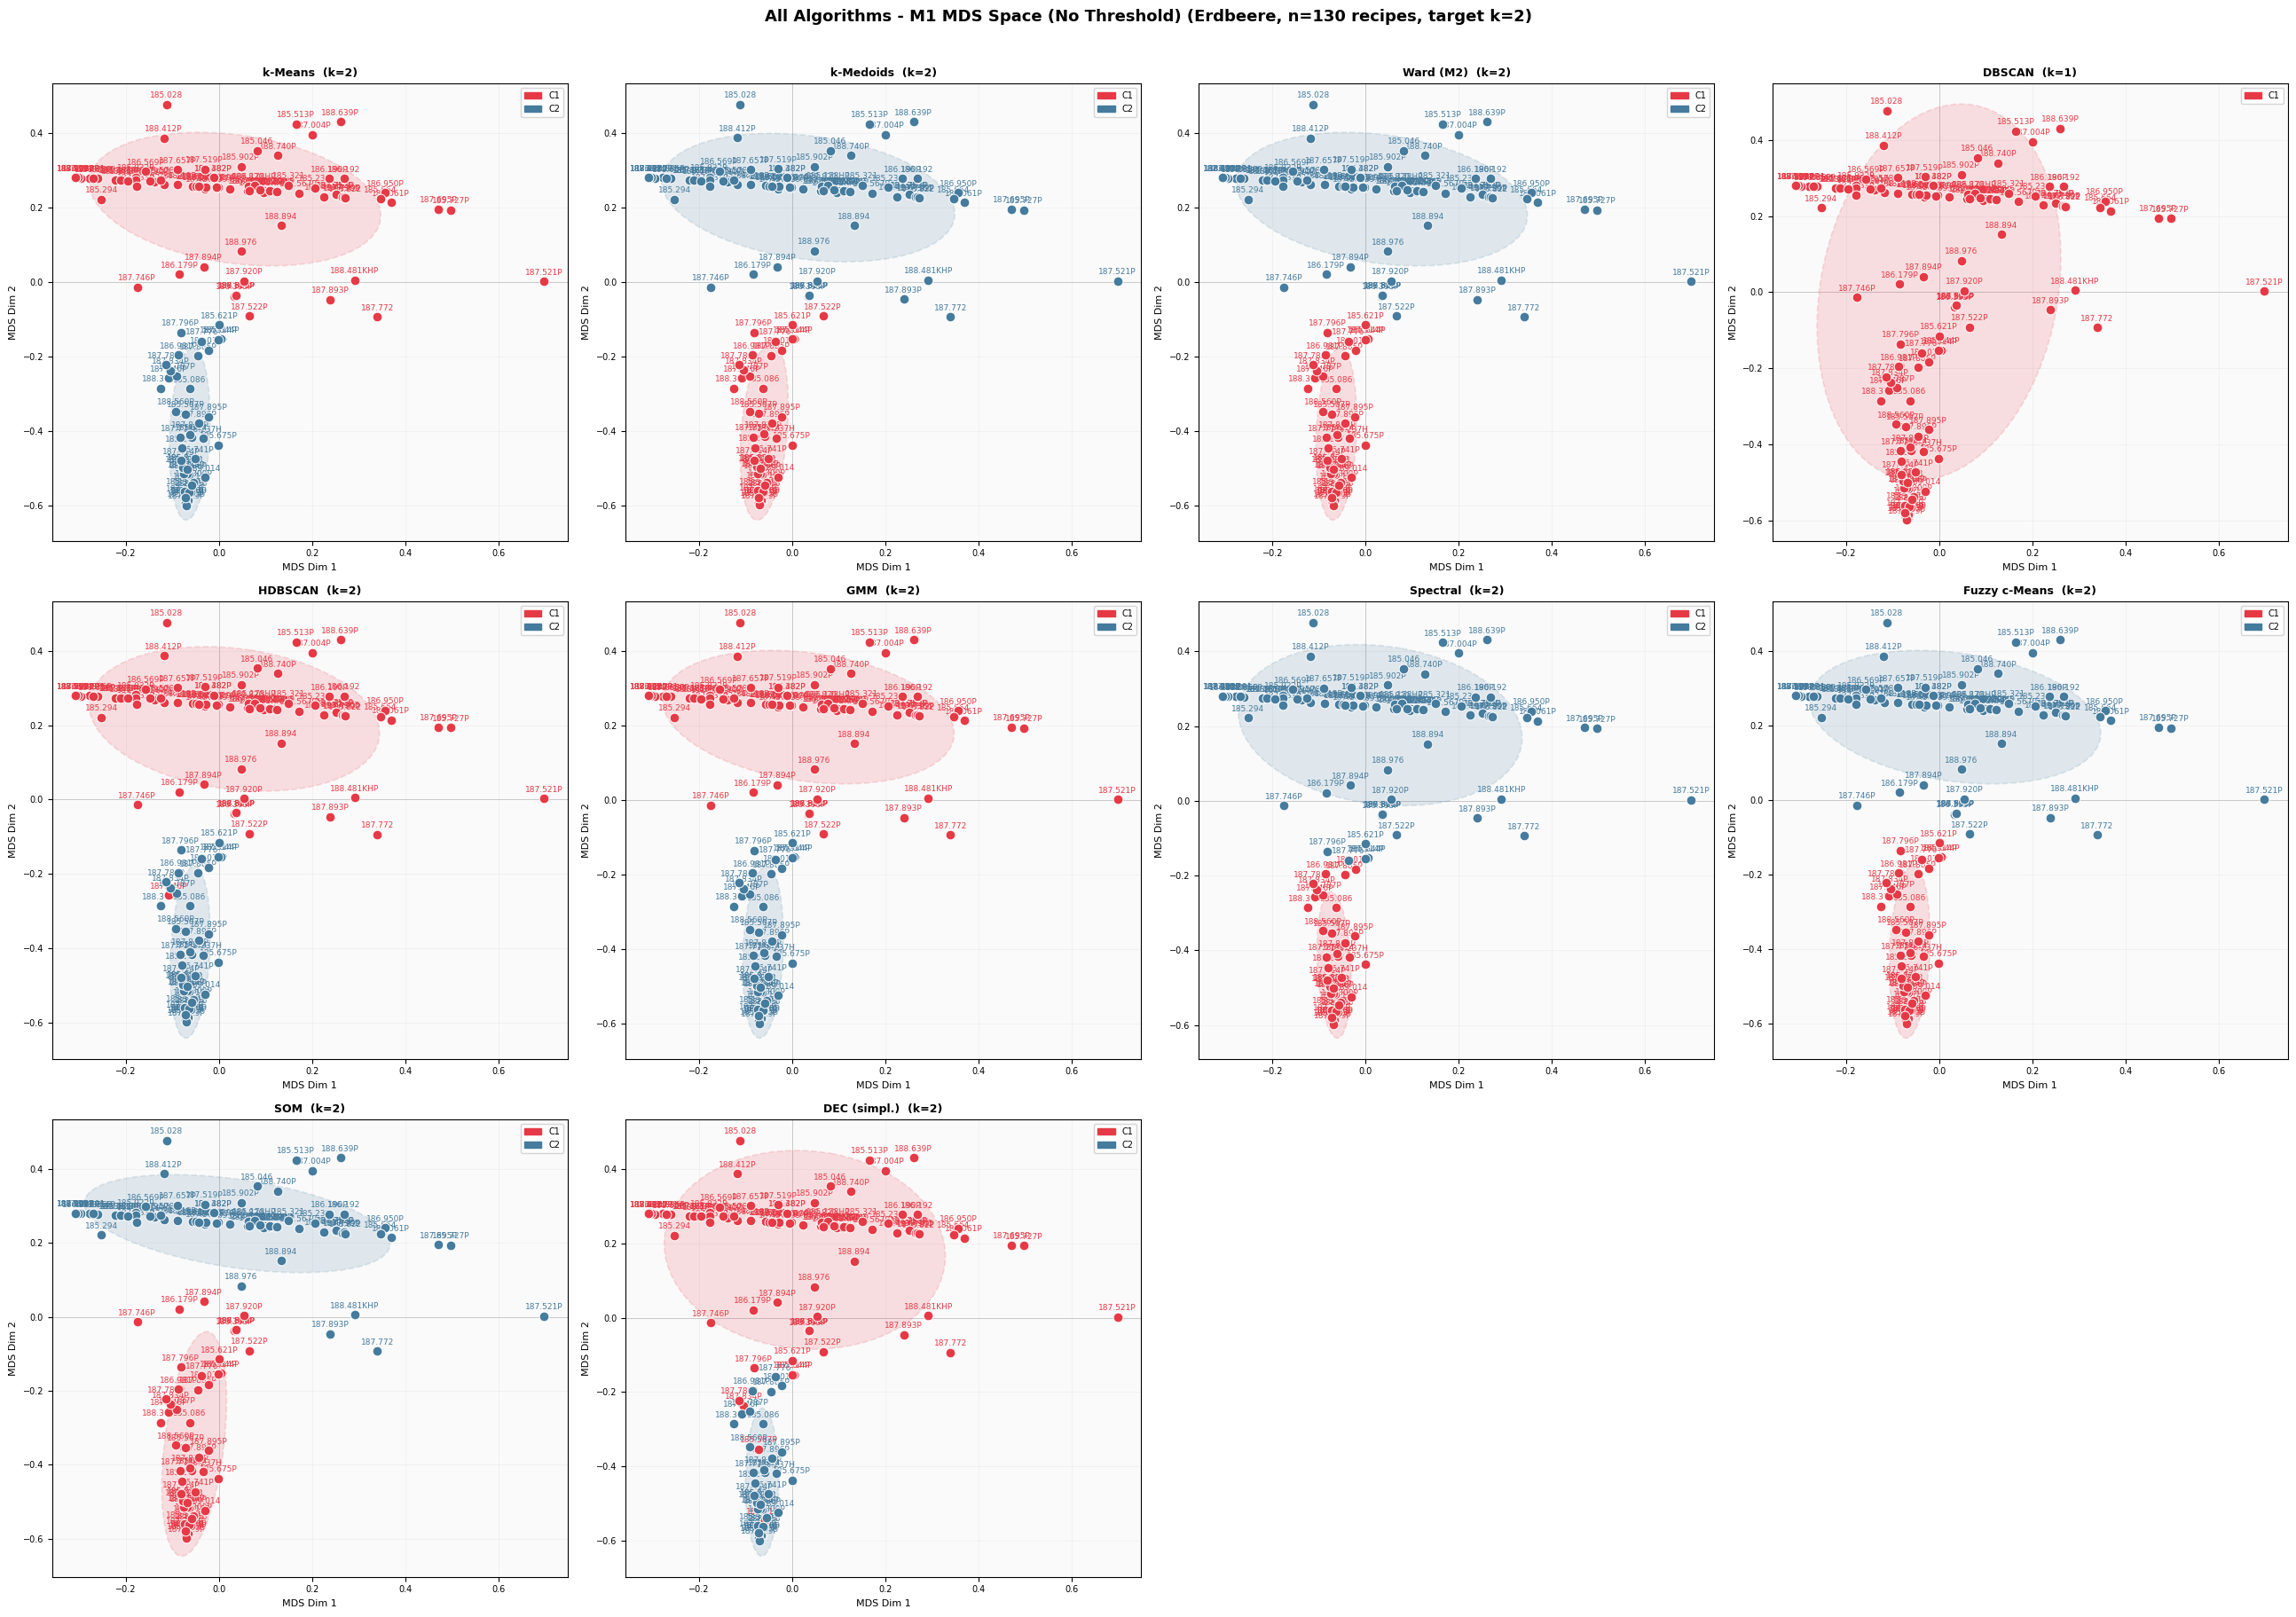

MDS grid saved.


In [10]:
n_algos = len(algo_labels_dict)
n_cols  = 4
n_rows  = -(-( n_algos ) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows))
axes = axes.flatten()

for ax_idx, (name, lbl) in enumerate(algo_labels_dict.items()):
    ax = axes[ax_idx]
    if lbl is None:
        ax.text(0.5, 0.5, f'{name}\n(not available)', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(name, fontsize=9, fontweight='bold')
        continue
    k_found = len(np.unique(lbl))
    mds_plot(ax, coords_m2, recipes, lbl,
             f'{name}  (k={k_found})', show_legend=True)

for i in range(ax_idx + 1, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'All Algorithms - M1 MDS Space (No Threshold) (Erdbeere, n={len(recipes)} recipes, target k={K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/erdbeere_v2_all_algorithms_mds.png', dpi=150, bbox_inches='tight')
plt.show()
print('MDS grid saved.')


## 6. Cross-Algorithm Agreement Analysis

Without a free-sorting ground truth, we compare algorithms **pairwise** using the same Hungarian optimal label alignment.

- **Agreement matrix**: % recipes where two algorithms agree after optimal label remapping  
- **Recipe stability**: for each recipe, count how many algorithm pairs agree on its cluster  
- **Consensus labels**: majority-vote cluster assignment across all algorithms

Pairwise agreement matrix (%, Hungarian-aligned):
               k-Means  k-Medoids  Ward (M2)  DBSCAN  HDBSCAN    GMM  Spectral  Fuzzy c-Means    SOM  DEC (simpl.)
k-Means          100.0       99.2      100.0    64.6     99.2  100.0      96.2          100.0   93.1          93.8
k-Medoids         99.2      100.0       99.2    63.8     98.5   99.2      95.4           99.2   93.8          93.1
Ward (M2)        100.0       99.2      100.0    64.6     99.2  100.0      96.2          100.0   93.1          93.8
DBSCAN            64.6       63.8       64.6   100.0     65.4   64.6      68.5           64.6   57.7          70.8
HDBSCAN           99.2       98.5       99.2    65.4    100.0   99.2      95.4           99.2   92.3          93.1
GMM              100.0       99.2      100.0    64.6     99.2  100.0      96.2          100.0   93.1          93.8
Spectral          96.2       95.4       96.2    68.5     95.4   96.2     100.0           96.2   89.2          96.2
Fuzzy c-Means    100.0       9

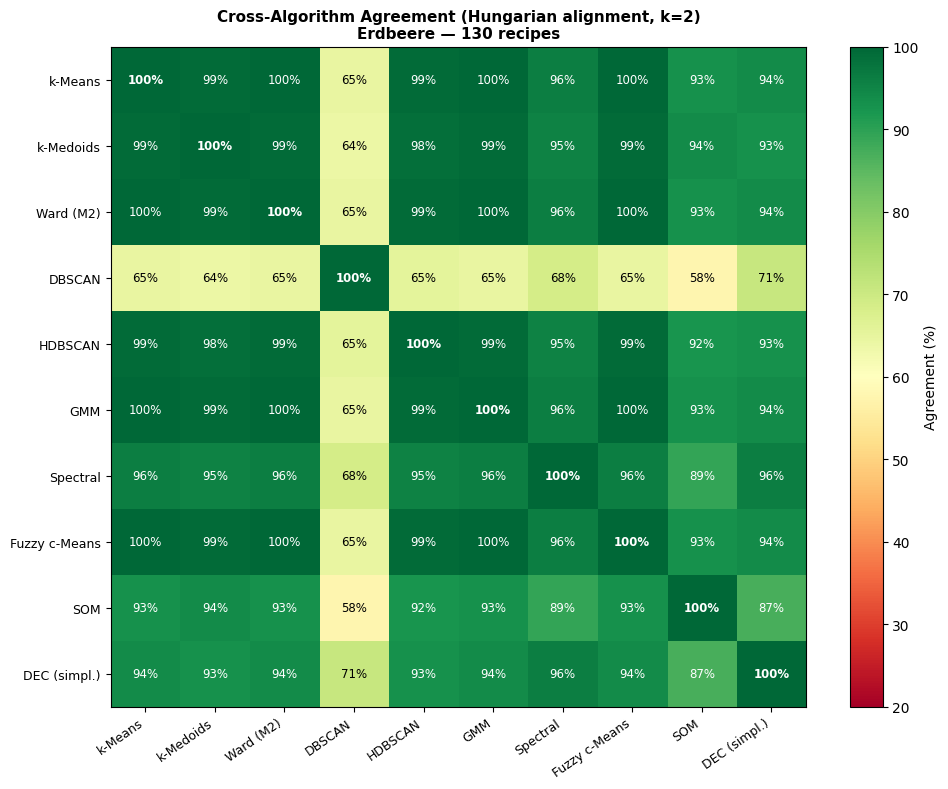

Agreement heatmap saved.


In [11]:
def pairwise_agreement(lbl_a, lbl_b, all_recipes):
    la = np.array([int(lbl_a[all_recipes.index(r)]) for r in all_recipes])
    lb = np.array([int(lbl_b[all_recipes.index(r)]) for r in all_recipes])
    ids_a = sorted(set(la)); ids_b = sorted(set(lb))
    conf  = np.zeros((len(ids_a), len(ids_b)), dtype=int)
    for i, j in zip(la, lb):
        conf[ids_a.index(i), ids_b.index(j)] += 1
    ri, ci = linear_sum_assignment(-conf)
    return 100.0 * sum(conf[r, c] for r, c in zip(ri, ci)) / len(all_recipes)

algo_names_avail = [n for n, l in algo_labels_dict.items() if l is not None]
n_avail          = len(algo_names_avail)
agree_matrix     = np.full((n_avail, n_avail), np.nan)

for i, name_i in enumerate(algo_names_avail):
    for j, name_j in enumerate(algo_names_avail):
        if i == j:
            agree_matrix[i, j] = 100.0
        else:
            agree_matrix[i, j] = pairwise_agreement(
                algo_labels_dict[name_i], algo_labels_dict[name_j], recipes)

print('Pairwise agreement matrix (%, Hungarian-aligned):')
df_agree = pd.DataFrame(agree_matrix, index=algo_names_avail, columns=algo_names_avail)
print(df_agree.round(1).to_string())

avg_agreement = np.nanmean(agree_matrix, axis=1)
print('\nAverage agreement with all other algorithms:')
for name, avg in sorted(zip(algo_names_avail, avg_agreement), key=lambda x: -x[1]):
    print(f'  {name:20s}  {avg:.1f}%')

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
masked = np.ma.masked_invalid(agree_matrix)
im = ax.imshow(masked, cmap='RdYlGn', vmin=20, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Agreement (%)')
ax.set_xticks(range(n_avail)); ax.set_yticks(range(n_avail))
ax.set_xticklabels(algo_names_avail, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(algo_names_avail, fontsize=9)
for i in range(n_avail):
    for j in range(n_avail):
        if not np.isnan(agree_matrix[i, j]):
            val = agree_matrix[i, j]
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8.5, color='black' if 30 < val < 80 else 'white',
                    fontweight='bold' if i == j else 'normal')
ax.set_title(f'Cross-Algorithm Agreement (Hungarian alignment, k={K})\n'
             f'Erdbeere — {len(recipes)} recipes', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/erdbeere_cross_algo_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Agreement heatmap saved.')


Reference algorithm for consensus: k-Means


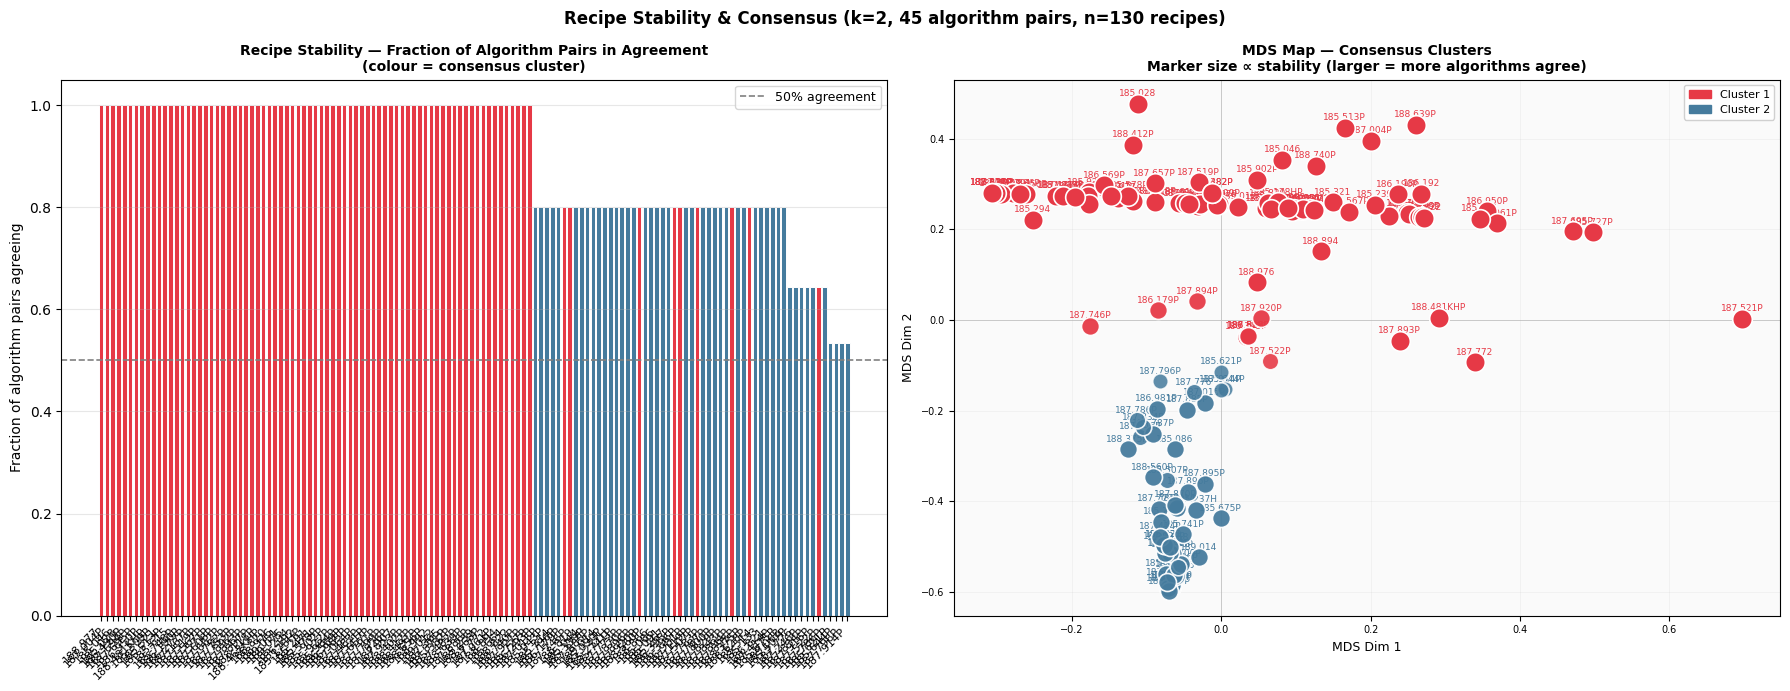

Stability plot saved.


In [12]:
from itertools import combinations

# For each recipe: fraction of algorithm pairs that agree on its cluster
# (after aligning each pair optimally)
def recipe_pair_agrees(lbl_a, lbl_b, all_recipes):
    """Returns dict recipe -> bool (does this recipe agree between lbl_a and lbl_b?)."""
    la = np.array([int(lbl_a[all_recipes.index(r)]) for r in all_recipes])
    lb = np.array([int(lbl_b[all_recipes.index(r)]) for r in all_recipes])
    ids_a = sorted(set(la)); ids_b = sorted(set(lb))
    conf  = np.zeros((len(ids_a), len(ids_b)), dtype=int)
    for i, j in zip(la, lb):
        conf[ids_a.index(i), ids_b.index(j)] += 1
    ri, ci = linear_sum_assignment(-conf)
    a_to_b = {ids_a[r]: ids_b[c] for r, c in zip(ri, ci)}
    return {r: (a_to_b.get(int(lbl_a[all_recipes.index(r)])) == int(lbl_b[all_recipes.index(r)]))
            for r in all_recipes}

avail_labels = [(n, algo_labels_dict[n]) for n in algo_names_avail]
pair_agree_counts = {r: 0 for r in recipes}
n_pairs = 0

for (ni, li), (nj, lj) in combinations(avail_labels, 2):
    agrees = recipe_pair_agrees(li, lj, recipes)
    for r in recipes:
        if agrees.get(r, False):
            pair_agree_counts[r] += 1
    n_pairs += 1

stability = {r: pair_agree_counts[r] / n_pairs for r in recipes}

# ── Majority-vote consensus cluster ──────────────────────────────────────────
# Align all algorithms to Ward (highest average agreement reference)
ref_name   = algo_names_avail[int(np.argmax(avg_agreement))]
ref_labels = algo_labels_dict[ref_name]
print(f'Reference algorithm for consensus: {ref_name}')

def align_to_ref(lbl_a, lbl_ref, all_recipes):
    la   = np.array([int(lbl_a[all_recipes.index(r)])   for r in all_recipes])
    lr   = np.array([int(lbl_ref[all_recipes.index(r)]) for r in all_recipes])
    ids_a = sorted(set(la)); ids_r = sorted(set(lr))
    conf  = np.zeros((len(ids_a), len(ids_r)), dtype=int)
    for i, j in zip(la, lr):
        conf[ids_a.index(i), ids_r.index(j)] += 1
    ri, ci = linear_sum_assignment(-conf)
    a_to_r = {ids_a[r]: ids_r[c] for r, c in zip(ri, ci)}
    return np.array([a_to_r.get(x, x) for x in la])

aligned_all = {}
for name, lbl in avail_labels:
    aligned_all[name] = align_to_ref(lbl, ref_labels, recipes)

# Majority vote
consensus_labels = np.array([
    Counter([aligned_all[n][i] for n in algo_names_avail]).most_common(1)[0][0]
    for i, r in enumerate(recipes)
])

# ── Stability plot ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: recipe stability bar chart
sorted_recipes = sorted(stability, key=stability.get, reverse=True)
sorted_stab    = [stability[r] for r in sorted_recipes]
colors_stab    = [CLUSTER_COLORS[(int(consensus_labels[recipes.index(r)]) - 1) % len(CLUSTER_COLORS)]
                  for r in sorted_recipes]
ax1.bar(range(len(sorted_recipes)), sorted_stab, color=colors_stab, edgecolor='white', lw=0.7)
ax1.axhline(0.5, color='gray', lw=1.2, linestyle='--', label='50% agreement')
ax1.set_xticks(range(len(sorted_recipes)))
ax1.set_xticklabels(sorted_recipes, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Fraction of algorithm pairs agreeing', fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.set_title('Recipe Stability — Fraction of Algorithm Pairs in Agreement\n(colour = consensus cluster)',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# Right: MDS map coloured by consensus + stability (marker size)
ax2.set_facecolor('#FAFAFA')
ax2.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
ax2.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)
for i, recipe in enumerate(recipes):
    cl   = int(consensus_labels[i])
    col  = CLUSTER_COLORS[(cl - 1) % len(CLUSTER_COLORS)]
    stab = stability[recipe]
    size = 40 + 160 * stab  # larger = more stable
    ax2.scatter(coords_m2[i, 0], coords_m2[i, 1], color=col, s=size, zorder=4,
                edgecolors='black' if stab < 0.5 else 'white', lw=1.2,
                alpha=0.7 + 0.3 * stab)
    ax2.annotate(recipe, (coords_m2[i, 0], coords_m2[i, 1]),
                 fontsize=6.5, ha='center', va='bottom',
                 xytext=(0, 4), textcoords='offset points', color=col)
ax2.set_title('MDS Map — Consensus Clusters\nMarker size ∝ stability (larger = more algorithms agree)',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('MDS Dim 1', fontsize=9)
ax2.set_ylabel('MDS Dim 2', fontsize=9)
ax2.grid(True, alpha=0.2, lw=0.4)
ax2.tick_params(labelsize=7)

unique_cl = sorted(set(consensus_labels))
patches   = [mpatches.Patch(color=CLUSTER_COLORS[(c-1)%len(CLUSTER_COLORS)], label=f'Cluster {c}')
             for c in unique_cl]
ax2.legend(handles=patches, fontsize=8, loc='best', framealpha=0.9)

fig.suptitle(f'Recipe Stability & Consensus (k={K}, {n_pairs} algorithm pairs, n={len(recipes)} recipes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/erdbeere_recipe_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stability plot saved.')


In [13]:
print('=== Recipe Cluster Assignments — All Algorithms ===\n')
from collections import Counter

header_parts = ['Recipe'] + algo_names_avail + ['Consensus', 'Stability']
rows_out = []
for i, recipe in enumerate(sorted(recipes)):
    ri = recipes.index(recipe)
    row = [recipe]
    for name in algo_names_avail:
        row.append(f'C{int(aligned_all[name][ri])}')
    row.append(f'C{int(consensus_labels[ri])}')
    row.append(f'{stability[recipe]:.0%}')
    rows_out.append(row)

df_summary = pd.DataFrame(rows_out, columns=header_parts)
print(df_summary.to_string(index=False))

print('\n=== Most Stable Recipes (stability ≥ 70%) ===')
stable = [(r, stability[r]) for r in recipes if stability[r] >= 0.70]
stable.sort(key=lambda x: -x[1])
for r, s in stable:
    print(f'  {r}  {s:.0%}')

print('\n=== Least Stable Recipes (stability < 50%) ===')
unstable = [(r, stability[r]) for r in recipes if stability[r] < 0.50]
unstable.sort(key=lambda x: x[1])
for r, s in unstable:
    print(f'  {r}  {s:.0%}')


=== Recipe Cluster Assignments — All Algorithms ===

    Recipe k-Means k-Medoids Ward (M2) DBSCAN HDBSCAN GMM Spectral Fuzzy c-Means SOM DEC (simpl.) Consensus Stability
   185.028      C1        C1        C1     C1      C1  C1       C1            C1  C1           C1        C1      100%
  185.043P      C2        C2        C2     C1      C2  C2       C2            C2  C2           C2        C2       80%
   185.044      C2        C2        C2     C1      C2  C2       C2            C2  C2           C2        C2       80%
   185.046      C1        C1        C1     C1      C1  C1       C1            C1  C1           C1        C1      100%
   185.086      C2        C2        C2     C1      C2  C2       C2            C2  C2           C2        C2       80%
  185.090P      C2        C2        C2     C1      C2  C2       C2            C2  C2           C2        C2       80%
   185.091      C2        C2        C2     C1      C2  C2       C2            C2  C2           C2        C2       80%
   

## 9. FAISS Spherical k-Means at Interpretable k

FAISS provides GPU/CPU-accelerated k-means using L2-normalised vectors, which is
equivalent to cosine-distance k-means (spherical k-means).  
Because `OPTIMAL_K = 128` is driven by Ward (near-unique fingerprints), we fix
`K_FAISS_LIST = [4, 5, 6, 8]` and compare the silhouette quality at each k.  
`k = 5` is the Silhouette-optimal value (score ≈ 0.58) and is used for profiles.

FAISS 1.13.2 available.
  k=4  silhouette=0.5876  sizes={np.int64(1): np.int64(45), np.int64(2): np.int64(19), np.int64(3): np.int64(30), np.int64(4): np.int64(36)}
  k=5  silhouette=0.5700  sizes={np.int64(1): np.int64(27), np.int64(2): np.int64(9), np.int64(3): np.int64(16), np.int64(4): np.int64(32), np.int64(5): np.int64(46)}
  k=6  silhouette=0.5768  sizes={np.int64(1): np.int64(27), np.int64(2): np.int64(8), np.int64(3): np.int64(11), np.int64(4): np.int64(22), np.int64(5): np.int64(46), np.int64(6): np.int64(16)}
  k=8  silhouette=0.5471  sizes={np.int64(1): np.int64(22), np.int64(2): np.int64(7), np.int64(3): np.int64(7), np.int64(4): np.int64(21), np.int64(5): np.int64(9), np.int64(6): np.int64(18), np.int64(7): np.int64(15), np.int64(8): np.int64(31)}

FAISS vs sklearn at k=5: 69.2% agreement (after Hungarian alignment)


WARNING clustering 130 points to 4 centroids: please provide at least 156 training points
WARNING clustering 130 points to 5 centroids: please provide at least 195 training points
WARNING clustering 130 points to 6 centroids: please provide at least 234 training points
WARNING clustering 130 points to 8 centroids: please provide at least 312 training points


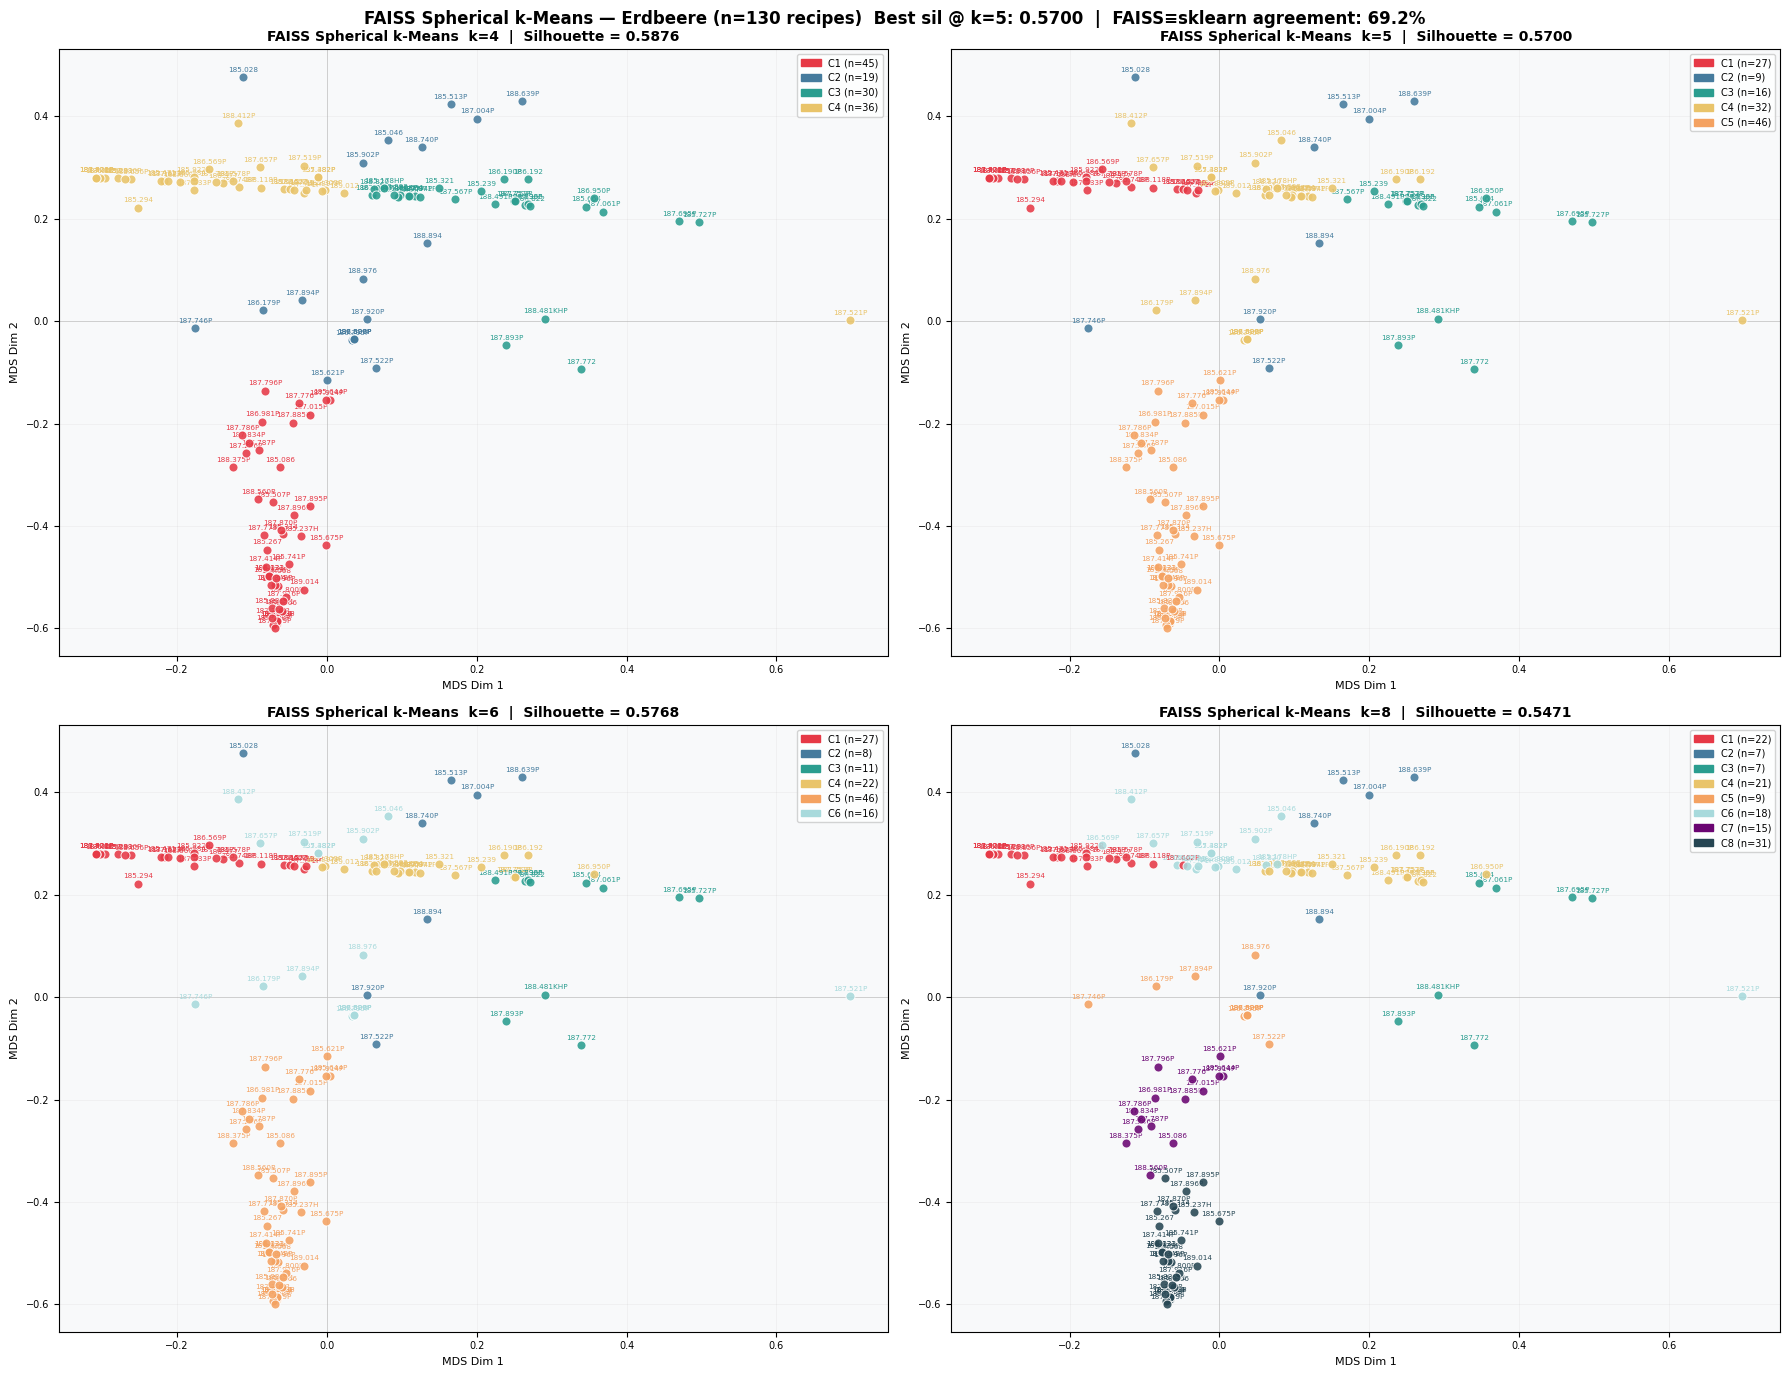

FAISS plot saved.


In [14]:
try:
    import faiss
    _has_faiss = True
    print(f"FAISS {faiss.__version__} available.")
except ImportError:
    _has_faiss = False
    print("⚠  FAISS not found — install with: pip install faiss-cpu")

K_FAISS_LIST = [4, 5, 6, 8]
faiss_results = {}        # k  → ndarray of 1-indexed labels (len = n_recipes)

if _has_faiss:
    # L2-normalise for spherical (cosine) k-means
    vf     = vecs_m2.astype(np.float32)
    nrm    = np.linalg.norm(vf, axis=1, keepdims=True)
    nrm[nrm == 0] = 1.0
    vf_n   = vf / nrm
    d      = vf_n.shape[1]

    sil_scores_faiss = {}
    for k in K_FAISS_LIST:
        km = faiss.Kmeans(d=d, k=k, niter=300, seed=42, spherical=True, verbose=False)
        km.train(vf_n)
        _, I = km.index.search(vf_n, 1)
        lbl = I.flatten() + 1          # 1-indexed
        faiss_results[k] = lbl
        sil = silhouette_score(diss_m2, lbl, metric='precomputed')
        sil_scores_faiss[k] = sil
        print(f"  k={k}  silhouette={sil:.4f}  sizes={dict(zip(*np.unique(lbl, return_counts=True)))}")

    # Compare FAISS vs sklearn k-Means at K_PROF=5
    K_PROF = 5
    km_sk  = KMeans(n_clusters=K_PROF, n_init=20, random_state=42).fit(vecs_m2)
    sk_lbl = km_sk.labels_ + 1
    sil_sk = silhouette_score(diss_m2, sk_lbl, metric='precomputed')

    # Align sklearn → FAISS with Hungarian matching
    ids_f = sorted(set(faiss_results[K_PROF]))
    ids_s = sorted(set(sk_lbl))
    conf  = np.zeros((len(ids_f), len(ids_s)), dtype=int)
    for i in range(len(recipes)):
        conf[ids_f.index(faiss_results[K_PROF][i]), ids_s.index(sk_lbl[i])] += 1
    ri, ci = linear_sum_assignment(-conf)
    s2f = {ids_s[ci[j]]: ids_f[ri[j]] for j in range(len(ri))}
    sk_aligned = np.array([s2f.get(v, v) for v in sk_lbl])
    agree = np.mean(faiss_results[K_PROF] == sk_aligned)
    print(f"\nFAISS vs sklearn at k={K_PROF}: {agree:.1%} agreement (after Hungarian alignment)")

    # ── MDS grid ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for ax_idx, k in enumerate(K_FAISS_LIST):
        ax  = axes[ax_idx]
        lbl = faiss_results[k]
        sil = sil_scores_faiss[k]
        ax.set_facecolor('#F8F9FA')
        ax.axhline(0, color='#CCCCCC', lw=0.6, zorder=1)
        ax.axvline(0, color='#CCCCCC', lw=0.6, zorder=1)

        for i, recipe in enumerate(recipes):
            cl  = int(lbl[i])
            col = CLUSTER_COLORS[(cl - 1) % len(CLUSTER_COLORS)]
            ax.scatter(coords_m2[i, 0], coords_m2[i, 1], color=col, s=42,
                       edgecolors='white', lw=0.7, zorder=4, alpha=0.88)
            ax.annotate(recipe, (coords_m2[i, 0], coords_m2[i, 1]),
                        fontsize=5.2, ha='center', va='bottom',
                        xytext=(0, 3), textcoords='offset points', color=col)

        clust_ids = sorted(set(lbl))
        patches = [mpatches.Patch(color=CLUSTER_COLORS[(c-1)%len(CLUSTER_COLORS)],
                                   label=f'C{c} (n={int(np.sum(lbl==c))})'
                                   ) for c in clust_ids]
        ax.legend(handles=patches, fontsize=7, loc='best', framealpha=0.85)
        ax.set_title(f'FAISS Spherical k-Means  k={k}  |  Silhouette = {sil:.4f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('MDS Dim 1', fontsize=8)
        ax.set_ylabel('MDS Dim 2', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2, lw=0.4)

    title_line = (f'FAISS Spherical k-Means — Erdbeere (n={len(recipes)} recipes)  '
                  f'Best sil @ k=5: {sil_scores_faiss[5]:.4f}  |  FAISS≡sklearn agreement: {agree:.1%}')
    fig.suptitle(title_line,
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/erdbeere_faiss_kmeans.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("FAISS plot saved.")
else:
    print("Skipping FAISS section.")
    K_PROF = 5
    faiss_results = {}


## 10. Cluster Profiles — OT Composition per Cluster (All Algorithms at k=5)

For each algorithm, clusters are re-fitted at **k = 5** (Silhouette-optimal).  
Each heatmap row is a cluster; columns are odour types.  
Colour intensity = mean share of total OAV from that odour type.  
This reveals whether algorithms discover the same flavour archetypes.

In [15]:
K_PROF = 5   # Silhouette-optimal

# -- Normalised Totalmenge x Odour-Type matrix --------------------------------
# Use the already-normalised Totalmenge (no OAV, no threshold)
df_ot    = df[df[TOTAL_COL] > 0].copy()
ot_vocab = sorted({str(x).strip() for x in df_ot[OT1].dropna()
                   if str(x).strip() not in ("", "nan")})

ot_matrix = pd.DataFrame(0.0, index=recipes, columns=ot_vocab)
for _, row in df_ot.iterrows():
    rez = row[REZ_COL]
    ot  = str(row[OT1]).strip()
    if rez in ot_matrix.index and ot in ot_vocab:
        ot_matrix.loc[rez, ot] += row[TOTAL_COL]   # already normalised proportion

row_sum = ot_matrix.sum(axis=1).replace(0, np.nan)
ot_prof = ot_matrix.div(row_sum, axis=0).fillna(0)

# -- Re-fit algorithms at K_PROF -----------------------------------------------
prof_algos = {}

km_p = KMeans(n_clusters=K_PROF, n_init=20, random_state=42).fit(vecs_m2)
prof_algos["k-Means"] = km_p.labels_ + 1

if _has_faiss and K_PROF in faiss_results:
    prof_algos["FAISS k-Means"] = faiss_results[K_PROF]

prof_algos["Ward"] = fcluster(Z_m2_sq, t=K_PROF, criterion="maxclust")

gmm_p = GaussianMixture(n_components=K_PROF, n_init=10, random_state=42).fit(vecs_m2)
prof_algos["GMM"] = gmm_p.predict(vecs_m2) + 1

prof_algos["k-Medoids"] = kmedoids(diss_m2, K_PROF, random_state=42)

spec_p = SpectralClustering(n_clusters=K_PROF, affinity="precomputed",
                             random_state=42, n_init=10).fit(1 - diss_m2)
prof_algos["Spectral"] = spec_p.labels_ + 1

prof_algos["Fuzzy c-Means"] = fuzzy_cmeans(vecs_m2, c=K_PROF, random_state=42)
prof_algos["SOM"] = som_cluster(vecs_m2, k=K_PROF, random_state=42)

print("Algorithms re-fitted at k=5:")
for name, lbl in prof_algos.items():
    sil = silhouette_score(diss_m2, np.array(lbl), metric="precomputed")
    print(f"  {name:<18s}  {len(np.unique(lbl))} clusters  sil={sil:.3f}")


Algorithms re-fitted at k=5:
  k-Means             5 clusters  sil=0.566
  FAISS k-Means       5 clusters  sil=0.570
  Ward                5 clusters  sil=0.591
  GMM                 5 clusters  sil=0.445
  k-Medoids           5 clusters  sil=0.581
  Spectral            5 clusters  sil=0.600
  Fuzzy c-Means       2 clusters  sil=0.653
  SOM                 5 clusters  sil=0.541


## 7. Key Findings (v2 - No Threshold)

### Data Processing
- Ignore list applied using CAS-based masking (covers all variants of a substance).
- Totalmenge normalised per recipe (sum = 1) - **no OAV / olfactory threshold**.
- Feature vectors are normalised proportion-weighted odour-type profiles.

### Models Compared
Only no-threshold models are used:
- **M1**: OT1 only
- **M2**: OT1 + OT2 + OT3 (position-weighted)

Without the threshold divisor, ingredients are weighted purely by their relative quantity.


## 8. Raw Vectors vs 2D MDS Coordinates — Algorithm Comparison

The algorithms above were applied to the **full M2 feature vectors** (high-dimensional, cosine distance).
Here we repeat the same 10 algorithms on the **2D MDS coordinates** (Euclidean distance)
and compare how much the two representations agree with each other.

This reveals whether the MDS compression preserves the cluster structure
or whether information is lost in the dimensionality reduction.

In [16]:
from scipy.spatial.distance import cdist as _cdist
from scipy.cluster.hierarchy import linkage as _linkage, fcluster as _fcluster

K_mds = OPTIMAL_K  # same target k as raw-vector run

# Euclidean distance matrix in 2D MDS space
dist_2d = _cdist(coords_m2, coords_m2, metric='euclidean')

# k-Means on 2D coords
lbl_mds_kmeans = KMeans(n_clusters=K_mds, n_init=100, random_state=42).fit_predict(coords_m2) + 1

# k-Medoids on 2D Euclidean distance
lbl_mds_kmedoids = kmedoids(dist_2d, k=K_mds)

# Ward linkage on 2D Euclidean
Z_2d = _linkage(coords_m2, method='ward', metric='euclidean')
lbl_mds_ward = _fcluster(Z_2d, t=K_mds, criterion='maxclust')

# DBSCAN scan in 2D Euclidean space
best_eps2d, best_raw2d = None, None
for eps in [round(v * 0.005, 4) for v in range(1, 601)]:
    raw = DBSCAN(eps=eps, min_samples=2).fit_predict(coords_m2)
    n_c = len(set(raw) - {-1})
    if best_eps2d is None or abs(n_c - K_mds) < abs(len(set(best_raw2d) - {-1}) - K_mds):
        best_eps2d, best_raw2d = eps, raw
    if n_c == K_mds and (raw == -1).sum() == 0:
        best_eps2d, best_raw2d = eps, raw
        break
lbl_mds_dbscan = resolve_noise(best_raw2d, dist_2d)
print(f'DBSCAN 2D: eps={best_eps2d:.3f}, {len(set(best_raw2d)-{-1})} clusters, '
      f'{(best_raw2d == -1).sum()} noise pts resolved')

# HDBSCAN scan in 2D
if _has_hdbscan:
    best_mcs2d, best_hdb2d = None, None
    for mcs in range(2, len(recipes) // 2 + 1):
        raw = _HDBSCAN(min_cluster_size=mcs).fit_predict(coords_m2)
        n_c = len(set(raw) - {-1})
        if best_mcs2d is None or abs(n_c - K_mds) < abs(len(set(best_hdb2d) - {-1}) - K_mds):
            best_mcs2d, best_hdb2d = mcs, raw
    lbl_mds_hdbscan = resolve_noise(best_hdb2d, dist_2d)
    print(f'HDBSCAN 2D: min_cluster_size={best_mcs2d}, '
          f'{len(set(best_hdb2d)-{-1})} clusters, '
          f'{(best_hdb2d == -1).sum()} noise pts resolved')
else:
    lbl_mds_hdbscan = None

# GMM on 2D
lbl_mds_gmm = GaussianMixture(n_components=K_mds, n_init=30, random_state=42).fit_predict(coords_m2) + 1

# Spectral with RBF affinity on 2D
lbl_mds_spectral = SpectralClustering(
    n_clusters=K_mds, affinity='rbf', n_init=100, random_state=42
).fit_predict(coords_m2) + 1

# Fuzzy c-Means on 2D coords
lbl_mds_fcm = fuzzy_cmeans(coords_m2, c=K_mds)

# SOM in 2D input space
lbl_mds_som = som_cluster(coords_m2, k=K_mds)

# DEC simplified on 2D (PCA is near-identity, essentially k-Means with cluster sharpening)
lbl_mds_dec = dec_simplified(coords_m2, n_clusters=K_mds)

algo_mds_labels = {
    'k-Means':       lbl_mds_kmeans,
    'k-Medoids':     lbl_mds_kmedoids,
    'Ward (M2)':     lbl_mds_ward,
    'DBSCAN':        lbl_mds_dbscan,
    'HDBSCAN':       lbl_mds_hdbscan,
    'GMM':           lbl_mds_gmm,
    'Spectral':      lbl_mds_spectral,
    'Fuzzy c-Means': lbl_mds_fcm,
    'SOM':           lbl_mds_som,
    'DEC (simpl.)':  lbl_mds_dec,
}

print('\nCluster counts on 2D MDS coords (target k={K_mds}):'.replace('{K_mds}', str(K_mds)))
for name, lbl in algo_mds_labels.items():
    if lbl is None:
        print(f'  {name:20s}  N/A')
    else:
        print(f'  {name:20s}  {len(np.unique(lbl))} clusters')


DBSCAN 2D: eps=0.110, 2 clusters, 1 noise pts resolved
HDBSCAN 2D: min_cluster_size=7, 2 clusters, 13 noise pts resolved

Cluster counts on 2D MDS coords (target k=2):
  k-Means               2 clusters
  k-Medoids             2 clusters
  Ward (M2)             2 clusters
  DBSCAN                2 clusters
  HDBSCAN               2 clusters
  GMM                   2 clusters
  Spectral              2 clusters
  Fuzzy c-Means         2 clusters
  SOM                   2 clusters
  DEC (simpl.)          1 clusters


Algorithm     | Raw vs MDS agreement
----------------------------------------
k-Means              | 100.0%
k-Medoids            | 99.2%
Ward (M2)            | 93.1%
DBSCAN               | 97.7%
HDBSCAN              | 90.0%
GMM                  | 100.0%
Spectral             | 96.9%
Fuzzy c-Means        | 100.0%
SOM                  | 97.7%
DEC (simpl.)         | 70.8%

Mean pairwise agreement — Raw vectors: 89.9%
Mean pairwise agreement — MDS 2D:      83.0%


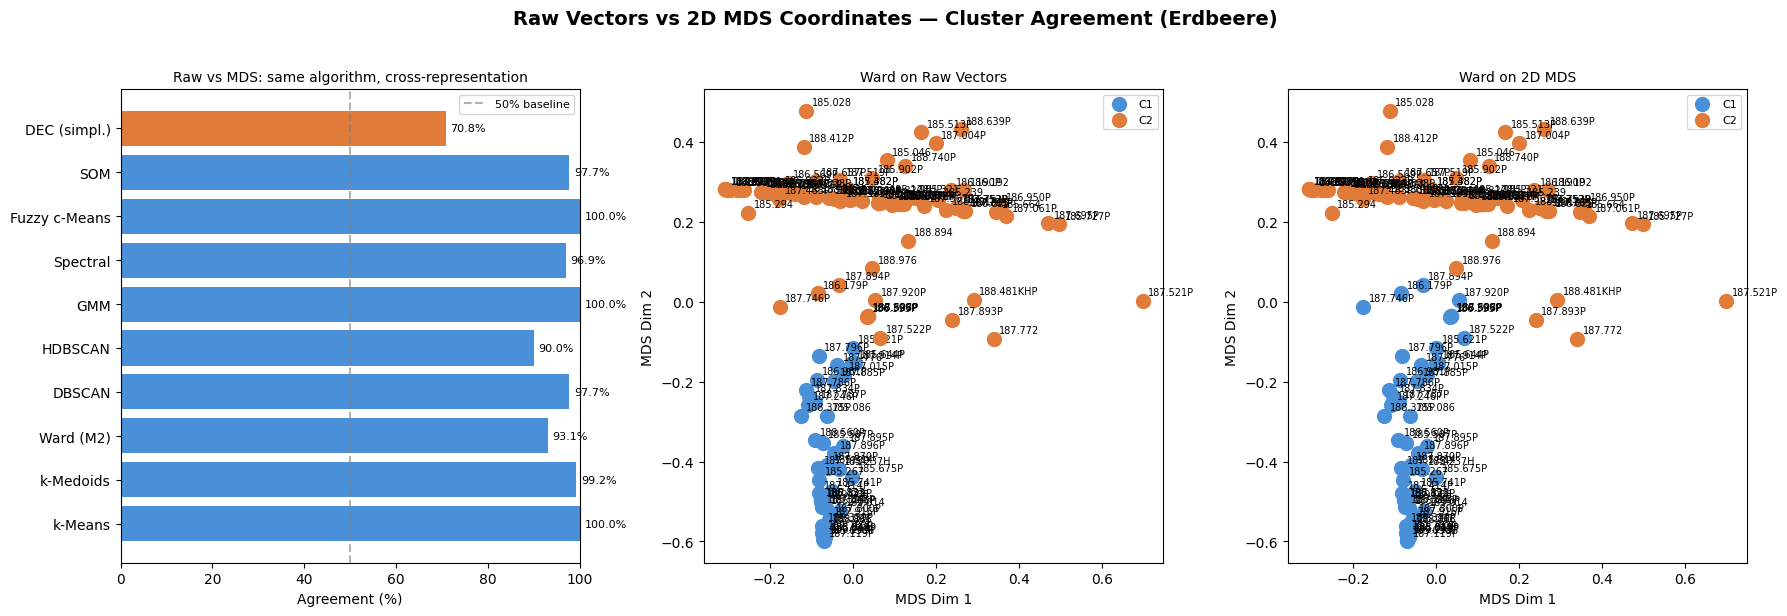

Saved: outputs/erdbeere_raw_vs_mds_comparison.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib
from itertools import combinations

# Average pairwise agreement for a label dictionary
def mean_pairwise_agreement(lbl_dict, all_recipes):
    names_avail = [n for n, l in lbl_dict.items() if l is not None]
    pairs = list(combinations(names_avail, 2))
    if not pairs:
        return 0.0
    scores = []
    for a, b in pairs:
        scores.append(pairwise_agreement(lbl_dict[a], lbl_dict[b], all_recipes))
    return float(np.mean(scores))

mean_raw = mean_pairwise_agreement(algo_labels_dict, recipes)
mean_mds = mean_pairwise_agreement(algo_mds_labels,  recipes)

# Per-algorithm: agreement of that algorithm (raw) with its MDS counterpart
raw_vs_mds_rows = []
for name in algo_labels_dict:
    lbl_r = algo_labels_dict[name]
    lbl_m = algo_mds_labels[name]
    if lbl_r is None or lbl_m is None:
        cross = None
    else:
        cross = pairwise_agreement(lbl_r, lbl_m, recipes)
    raw_vs_mds_rows.append((name, cross))

print('Algorithm     | Raw vs MDS agreement')
print('-' * 40)
for name, v in raw_vs_mds_rows:
    print(f'{name:20s} | {"N/A" if v is None else f"{v:.1f}%"}')
print(f'\nMean pairwise agreement — Raw vectors: {mean_raw:.1f}%')
print(f'Mean pairwise agreement — MDS 2D:      {mean_mds:.1f}%')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Raw Vectors vs 2D MDS Coordinates — Cluster Agreement (Erdbeere)',
             fontsize=14, fontweight='bold', y=1.02)

# Left: per-algorithm raw vs MDS cross-agreement
names_plot  = [r[0] for r in raw_vs_mds_rows if r[1] is not None]
values_plot = [r[1] for r in raw_vs_mds_rows if r[1] is not None]
colors_bar  = ['#4a90d9' if v >= 80 else '#e07b39' if v >= 60 else '#cc3333'
               for v in values_plot]
axes[0].barh(names_plot, values_plot, color=colors_bar)
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.6, label='50% baseline')
axes[0].set_xlabel('Agreement (%)')
axes[0].set_title('Raw vs MDS: same algorithm, cross-representation', fontsize=10)
axes[0].set_xlim(0, 100)
for i, v in enumerate(values_plot):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)
axes[0].legend(fontsize=8)

# Middle: MDS scatter colored by each algo (raw vs MDS side by side for Ward)
ward_raw = algo_labels_dict.get('Ward (M2)')
ward_mds = algo_mds_labels.get('Ward (M2)')
palette  = ['#4a90d9', '#e07b39', '#3ab57a', '#cc3333',
            '#9b59b6', '#f1c40f', '#1abc9c', '#e74c3c']

for ax, lbl, title in [(axes[1], ward_raw, 'Ward on Raw Vectors'),
                        (axes[2], ward_mds, 'Ward on 2D MDS')]:
    if lbl is None:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    uniq = sorted(set(lbl))
    for ci, c in enumerate(uniq):
        mask = np.array(lbl) == c
        xs = coords_m2[mask, 0]
        ys = coords_m2[mask, 1]
        ax.scatter(xs, ys, s=100, color=palette[ci % len(palette)],
                   label=f'C{c}', zorder=3)
        for j, r in enumerate(np.array(recipes)[mask]):
            ax.annotate(r, (xs[j], ys[j]), fontsize=7,
                        xytext=(4, 4), textcoords='offset points')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('MDS Dim 1')
    ax.set_ylabel('MDS Dim 2')

plt.tight_layout()
plt.savefig('../outputs/erdbeere_raw_vs_mds_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/erdbeere_raw_vs_mds_comparison.png')


---
## 11 · All Algorithms at Optimal k - M1 Feature Space (No Threshold)

Silhouette best k and Davies-Bouldin best k determined above.
All 10 algorithms are run at both k values; recipes are plotted in MDS Dim1 x Dim2 space.


In [18]:
CLUSTER_COLORS_10 = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
    '#F4A261', '#A8DADC', '#6A0572', '#264653',
    '#F72585', '#4CC9F0',
]

def _resolve_noise(raw, dist_matrix):
    labels    = raw.copy()
    noise     = np.where(labels == -1)[0]
    non_noise = np.where(labels != -1)[0]
    if len(noise) == 0:     return labels + 1
    if len(non_noise) == 0: return np.ones(len(labels), dtype=int)
    for i in noise:
        labels[i] = labels[non_noise[np.argmin(dist_matrix[i, non_noise])]]
    return labels + 1

def _fuzzy_cmeans(X, c, m=2.0, max_iter=500, tol=1e-7, random_state=42):
    rng = np.random.RandomState(random_state)
    U   = rng.dirichlet(np.ones(c), X.shape[0]).T
    for _ in range(max_iter):
        Um   = U ** m
        cent = (Um @ X) / Um.sum(axis=1, keepdims=True)
        d    = np.array([[np.linalg.norm(X[j] - cent[i]) for j in range(X.shape[0])] for i in range(c)])
        d    = np.maximum(d, 1e-12)
        ratio = d[None, :, :] / d[:, None, :]
        U_new = 1.0 / (ratio ** (2.0 / (m - 1))).sum(axis=1)
        U_new /= U_new.sum(axis=0, keepdims=True)
        if np.max(np.abs(U_new - U)) < tol: break
        U = U_new
    return np.argmax(U, axis=0) + 1

def _som_cluster(X, k, lr=0.5, sigma=1.5, n_iter=10000, random_state=42):
    rng    = np.random.RandomState(random_state)
    g      = int(np.ceil(np.sqrt(k)))
    n_n    = g * g
    W      = normalize(rng.randn(n_n, X.shape[1]))
    pos    = np.array([(r, c) for r in range(g) for c in range(g)], dtype=float)
    for t in range(n_iter):
        frac  = 1.0 - t / n_iter
        lr_t  = lr * frac;  sig_t = max(sigma * frac, 0.01)
        xi    = X[rng.randint(0, X.shape[0])]
        bmu   = np.argmin(np.linalg.norm(W - xi, axis=1))
        h     = np.exp(-((pos - pos[bmu]) ** 2).sum(axis=1) / (2 * sig_t ** 2))
        W    += lr_t * h[:, None] * (xi - W)
    node_lbl = KMeans(n_clusters=k, n_init=30, random_state=random_state).fit_predict(W)
    return np.array([node_lbl[np.argmin(np.linalg.norm(W - xi, axis=1))] for xi in X]) + 1

def _dec(X, n_clusters, enc_dim=8, n_iter=300, random_state=42):
    d = min(enc_dim, X.shape[1], X.shape[0] - 1)
    Z = PCA(n_components=d, random_state=random_state).fit_transform(X)
    c = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state).fit(Z).cluster_centers_.copy()
    for _ in range(n_iter):
        dist2  = np.sum((Z[:, None, :] - c[None, :, :]) ** 2, axis=2)
        q      = 1.0 / (1.0 + dist2);  q /= q.sum(axis=1, keepdims=True)
        f      = q.sum(axis=0)
        p      = (q ** 2) / np.maximum(f, 1e-12);  p /= p.sum(axis=1, keepdims=True)
        for j in range(n_clusters):
            c[j] = (p[:, j:j+1] * Z).sum(axis=0) / max(p[:, j].sum(), 1e-12)
    return np.argmax(q, axis=1) + 1

print('Algorithm helpers ready.')


Algorithm helpers ready.


In [19]:
K_SIL_MDS = best_k_sil   # Silhouette best k (from auto-detection above)
K_DB_MDS  = best_k_db    # Davies-Bouldin best k

# Feature space: M1 recipe vectors (no threshold, already computed above)
feats_mds   = vecs_m2
feats_mds_n = normalize(feats_mds)
diss_mds    = diss_m2
recipes_mds = list(recipes)
n_mds       = n
print(f"Feature space : {feats_mds.shape}")
print(f"Distance matrix: {diss_mds.shape}")
print(f"Silhouette best k = {K_SIL_MDS}  |  Davies-Bouldin best k = {K_DB_MDS}")


Feature space : (130, 13)
Distance matrix: (130, 130)
Silhouette best k = 2  |  Davies-Bouldin best k = 2


In [20]:
def run_all_algos_mds(K):
    """Run all 10 algorithms at k=K using M2 feature space."""
    res = {}

    # Ward hierarchical
    Z_w = linkage(squareform(diss_mds, checks=False), method='ward')
    res['Ward'] = fcluster(Z_w, K, criterion='maxclust')

    # k-Means
    res['k-Means'] = KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(feats_mds) + 1

    # k-Medoids
    res['k-Medoids'] = kmedoids(diss_mds, k=K)

    # GMM
    enc_g = min(K, feats_mds.shape[0]-1, feats_mds.shape[1])
    Zg    = PCA(n_components=enc_g, random_state=42).fit_transform(feats_mds)
    res['GMM'] = GaussianMixture(n_components=K, n_init=30, covariance_type='full',
                                  random_state=42).fit_predict(Zg) + 1

    # Spectral
    aff = np.clip(1.0 - diss_mds, 0.0, 1.0); np.fill_diagonal(aff, 1.0)
    res['Spectral'] = SpectralClustering(n_clusters=K, affinity='precomputed',
                                          n_init=100, random_state=42).fit_predict(aff) + 1

    # DBSCAN — scan for best eps
    best_eps, best_raw = None, None
    for eps in np.arange(0.01, 2.0, 0.01):
        raw     = DBSCAN(eps=eps, min_samples=2, metric='precomputed').fit_predict(diss_mds)
        n_clust = len(set(raw) - {-1})
        if best_eps is None or abs(n_clust - K) < abs(len(set(best_raw) - {-1}) - K):
            best_eps, best_raw = eps, raw
        if n_clust == K and (raw == -1).sum() == 0:
            best_eps, best_raw = eps, raw; break
    res['DBSCAN'] = _resolve_noise(best_raw, diss_mds)

    # HDBSCAN
    if _has_hdbscan:
        best_mcs, best_raw_h = None, None
        for mcs in range(2, n_mds + 1):
            raw     = _HDBSCAN(min_cluster_size=mcs, metric='precomputed').fit_predict(diss_mds)
            n_clust = len(set(raw) - {-1})
            if best_mcs is None or abs(n_clust - K) < abs(len(set(best_raw_h) - {-1}) - K):
                best_mcs, best_raw_h = mcs, raw
        res['HDBSCAN'] = _resolve_noise(best_raw_h, diss_mds)
    else:
        res['HDBSCAN'] = None

    # Fuzzy c-Means
    enc_f = min(max(K, 4), feats_mds.shape[0]-1, feats_mds.shape[1])
    Zf    = PCA(n_components=enc_f, random_state=42).fit_transform(feats_mds)
    res['Fuzzy c-Means'] = _fuzzy_cmeans(Zf, c=K)

    # SOM
    enc_s = min(8, feats_mds.shape[0]-1, feats_mds.shape[1])
    Zs    = PCA(n_components=enc_s, random_state=42).fit_transform(feats_mds)
    res['SOM'] = _som_cluster(Zs, k=K)

    # DEC
    res['DEC (simpl.)'] = _dec(feats_mds, n_clusters=K)

    print(f'k={K} — actual cluster counts:')
    for name, lbl in res.items():
        if lbl is None: print(f'  {name:20s}  N/A'); continue
        counts = dict(zip(*np.unique(lbl, return_counts=True)))
        print(f'  {name:20s}  k_actual={len(counts)}  {counts}')
    return res


def plot_algo_grid_mds(algo_dict, K, subtitle, fname):
    n_algos = len(algo_dict)
    n_cols  = 4
    n_rows  = -(-n_algos // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5.5 * n_rows))
    axes = axes.flatten()

    for ax_idx, (name, lbl) in enumerate(algo_dict.items()):
        ax = axes[ax_idx]
        if lbl is None:
            ax.text(0.5, 0.5, f'{name}\n(not available)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_title(name, fontsize=9, fontweight='bold')
            continue
        k_actual = len(np.unique(lbl))
        colors   = [CLUSTER_COLORS_10[(c - 1) % len(CLUSTER_COLORS_10)] for c in lbl]
        ax.scatter(coords_m2[:, 0], coords_m2[:, 1], c=colors,
                   s=55, alpha=0.82, edgecolors='white', linewidths=0.4, zorder=3)
        handles = [mpatches.Patch(color=CLUSTER_COLORS_10[(c-1) % len(CLUSTER_COLORS_10)],
                                   label=f'C{c}') for c in sorted(np.unique(lbl))]
        ax.legend(handles=handles, fontsize=7, ncol=min(k_actual, 5),
                  loc='upper right', framealpha=0.7)
        ax.axhline(0, color='grey', lw=0.4, ls='--')
        ax.axvline(0, color='grey', lw=0.4, ls='--')
        ax.set_xlabel('Dim1', fontsize=8)
        ax.set_ylabel('Dim2', fontsize=8)
        ax.set_title(f'{name}  (k={k_actual})', fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)

    for i in range(ax_idx + 1, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(
        f'All Algorithms — M2 Feature Space  (Erdbeere, n={n_mds} recipes, {subtitle})',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

print('run_all_algos_mds and plot_algo_grid_mds defined.')


run_all_algos_mds and plot_algo_grid_mds defined.


k = 2  -- Silhouette optimum
k=2 — actual cluster counts:
  Ward                  k_actual=2  {np.int32(1): np.int64(46), np.int32(2): np.int64(84)}
  k-Means               k_actual=2  {np.int32(1): np.int64(84), np.int32(2): np.int64(46)}
  k-Medoids             k_actual=2  {np.int64(1): np.int64(47), np.int64(2): np.int64(83)}
  GMM                   k_actual=2  {np.int64(1): np.int64(84), np.int64(2): np.int64(46)}
  Spectral              k_actual=2  {np.int32(1): np.int64(41), np.int32(2): np.int64(89)}
  DBSCAN                k_actual=1  {np.int64(1): np.int64(130)}
  HDBSCAN               k_actual=2  {np.int64(1): np.int64(85), np.int64(2): np.int64(45)}
  Fuzzy c-Means         k_actual=2  {np.int64(1): np.int64(46), np.int64(2): np.int64(84)}
  SOM                   k_actual=2  {np.int32(1): np.int64(55), np.int32(2): np.int64(75)}
  DEC (simpl.)          k_actual=2  {np.int64(1): np.int64(92), np.int64(2): np.int64(38)}


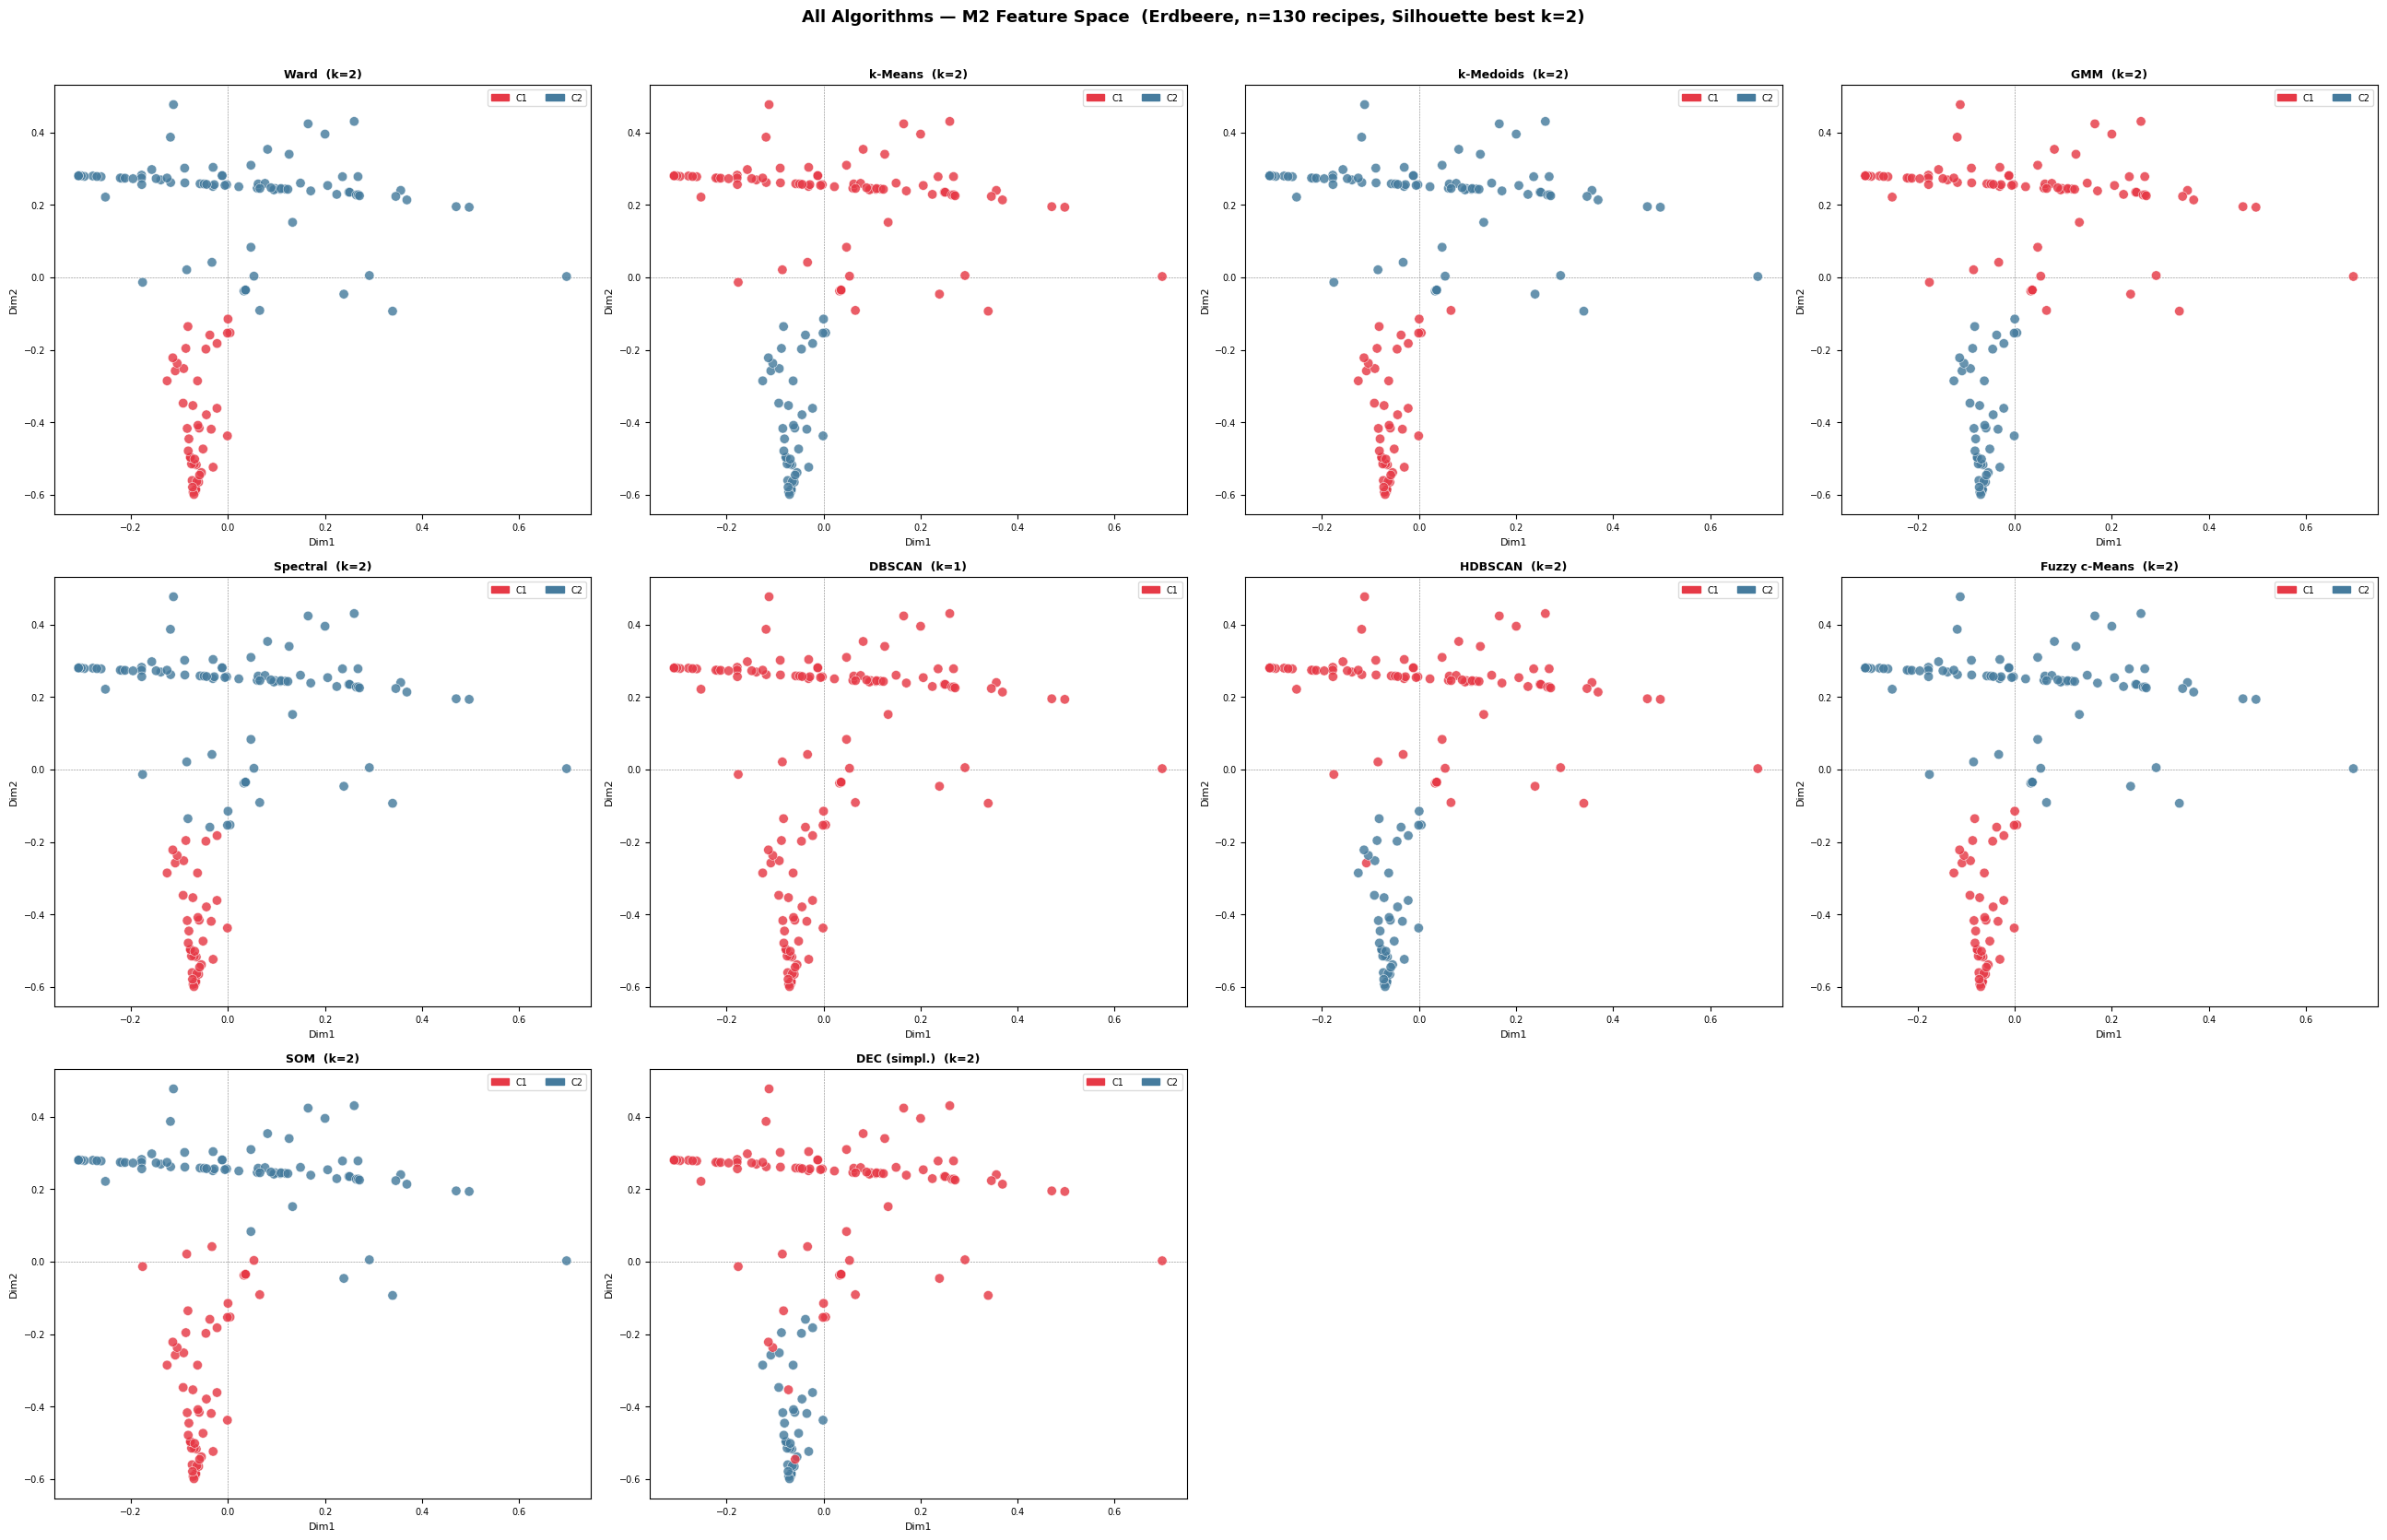

Saved: erdbeere_v2_mds_all_algos_k2_silhouette.png


In [21]:
print("=" * 60)
print(f"k = {K_SIL_MDS}  -- Silhouette optimum")
print("=" * 60)
algo_k5_mds = run_all_algos_mds(K_SIL_MDS)
plot_algo_grid_mds(
    algo_k5_mds, K_SIL_MDS,
    subtitle=f"Silhouette best k={K_SIL_MDS}",
    fname=f"erdbeere_v2_mds_all_algos_k{K_SIL_MDS}_silhouette.png"
)


k = 2  -- Davies-Bouldin optimum
k=2 — actual cluster counts:
  Ward                  k_actual=2  {np.int32(1): np.int64(128), np.int32(2): np.int64(2)}
  k-Means               k_actual=2  {np.int32(1): np.int64(84), np.int32(2): np.int64(46)}
  k-Medoids             k_actual=1  {np.int64(1): np.int64(130)}
  GMM                   k_actual=2  {np.int64(1): np.int64(84), np.int64(2): np.int64(46)}
  Spectral              k_actual=2  {np.int32(1): np.int64(128), np.int32(2): np.int64(2)}
  DBSCAN                k_actual=1  {np.int64(1): np.int64(130)}
  HDBSCAN               k_actual=2  {np.int64(1): np.int64(44), np.int64(2): np.int64(86)}
  Fuzzy c-Means         k_actual=2  {np.int64(1): np.int64(46), np.int64(2): np.int64(84)}
  SOM                   k_actual=2  {np.int32(1): np.int64(55), np.int32(2): np.int64(75)}
  DEC (simpl.)          k_actual=2  {np.int64(1): np.int64(92), np.int64(2): np.int64(38)}


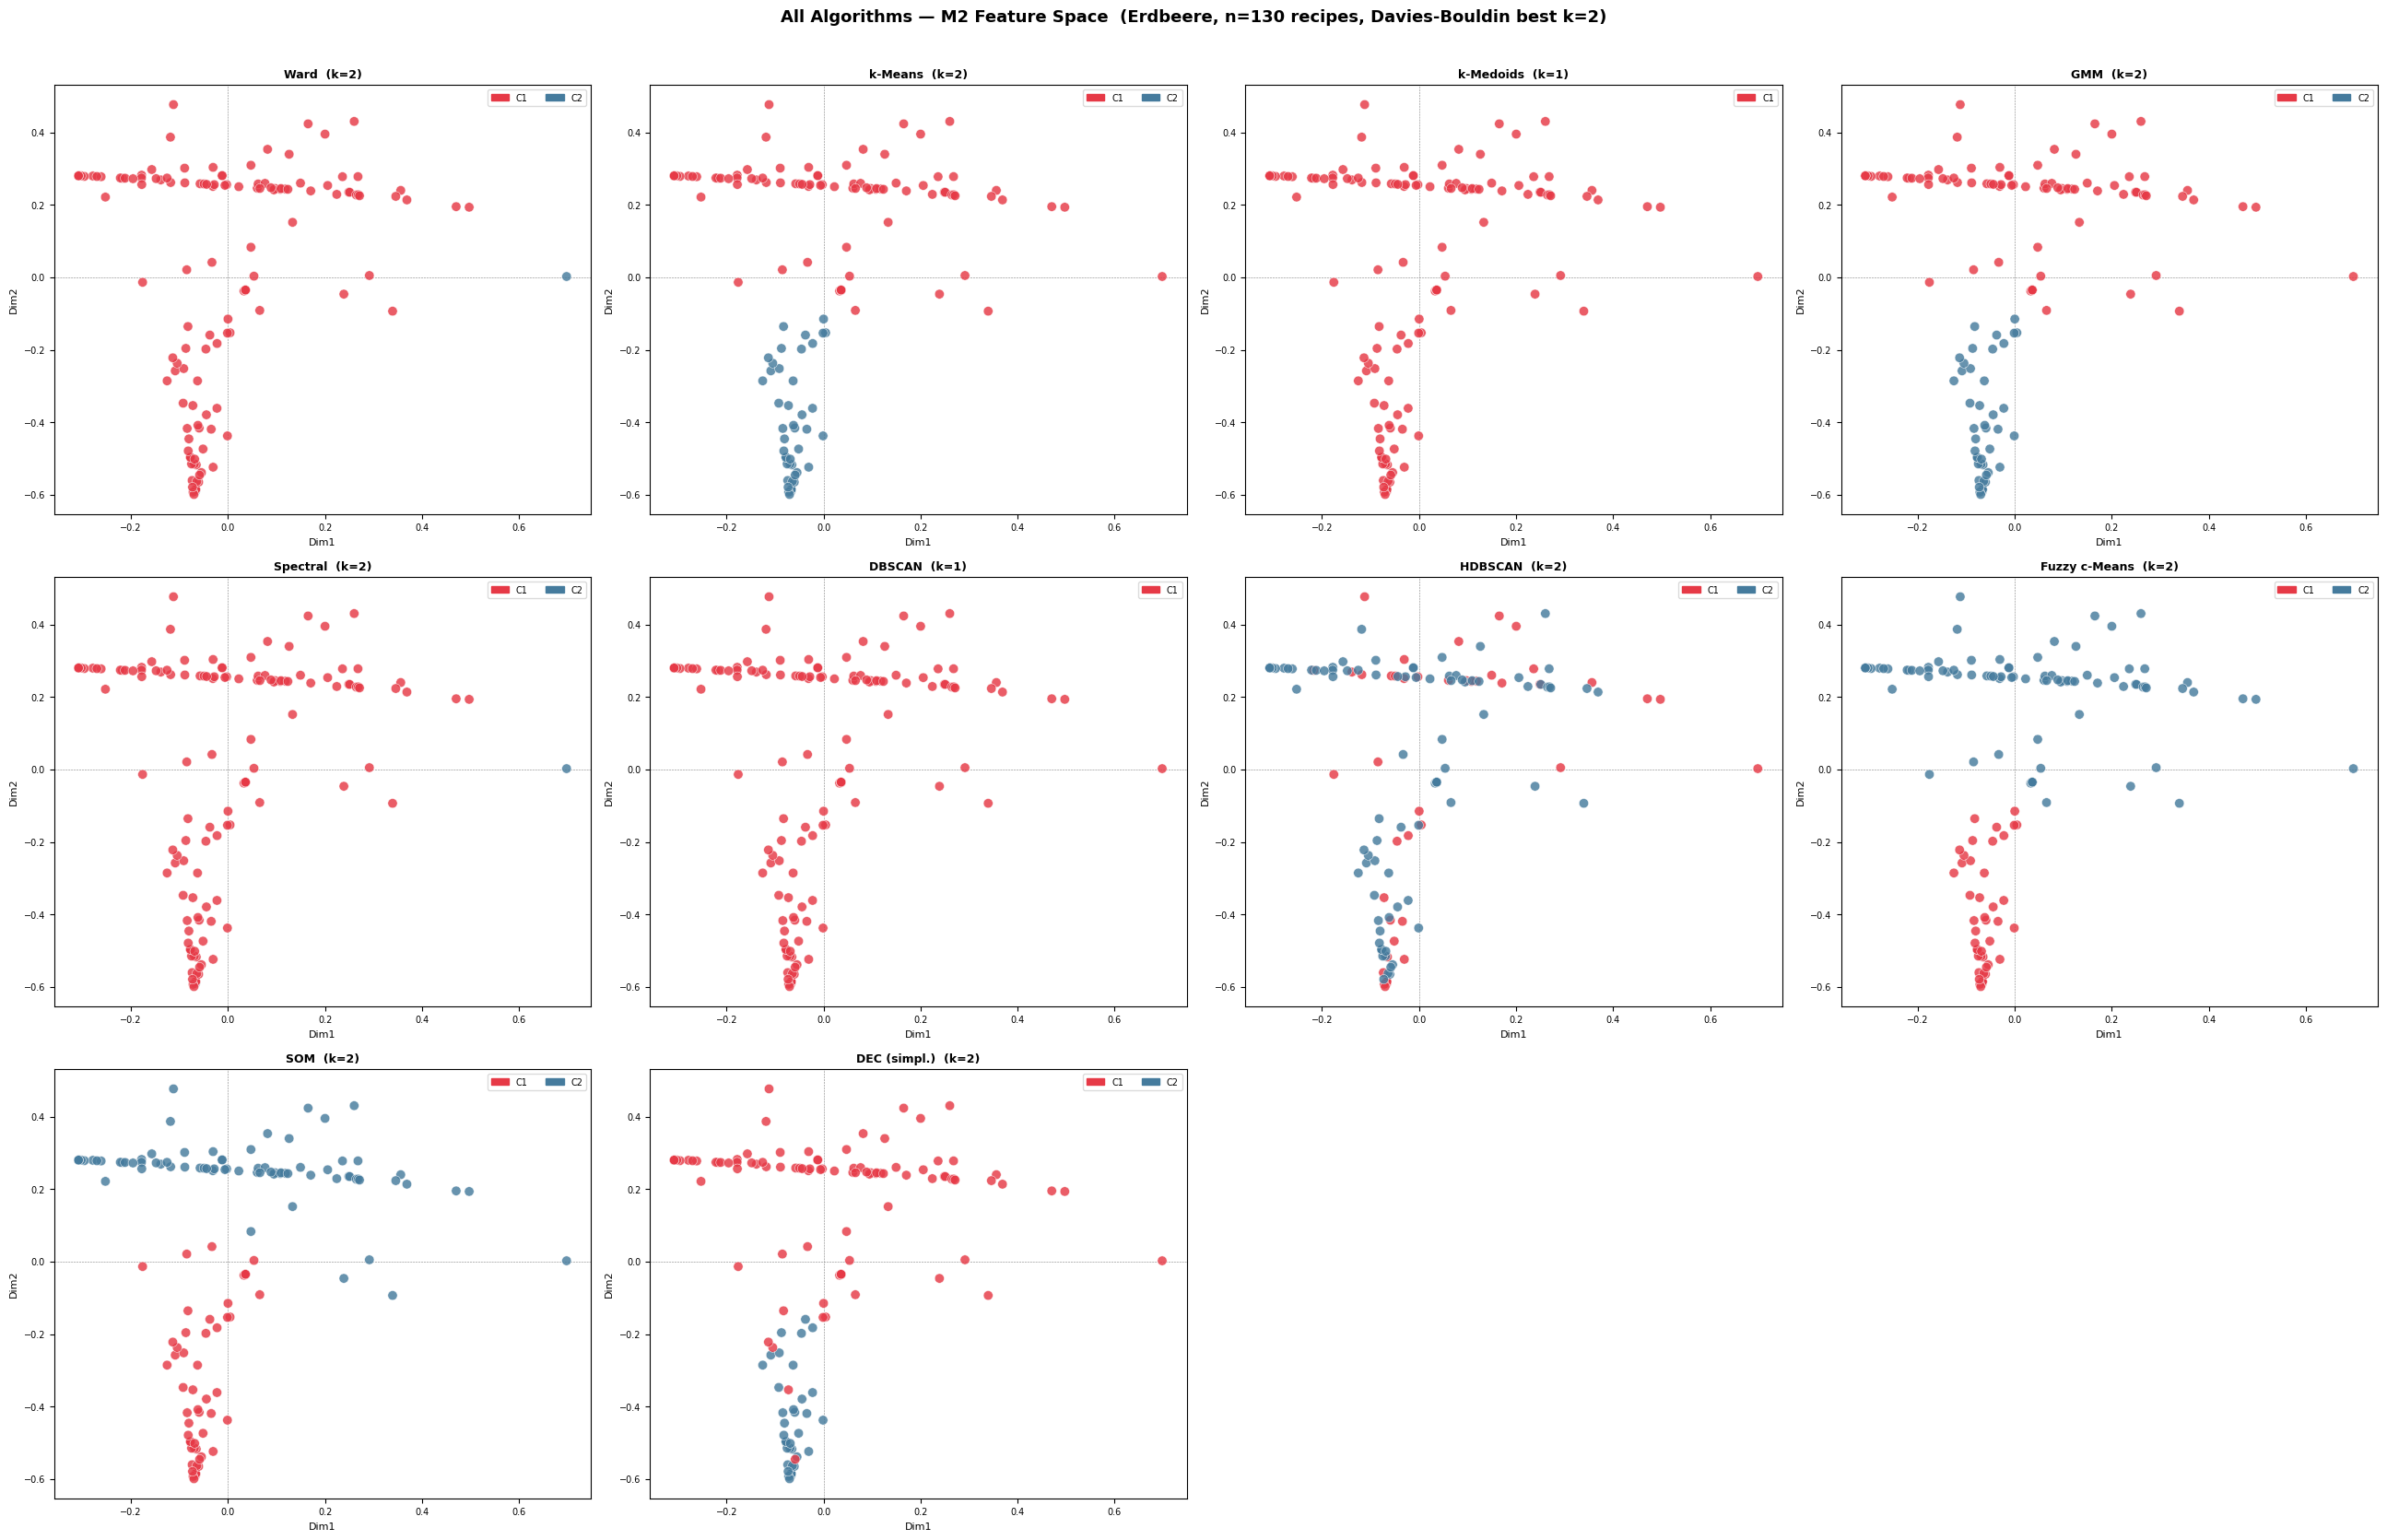

Saved: erdbeere_v2_mds_all_algos_k2_davies_bouldin.png


In [22]:
print("=" * 60)
print(f"k = {K_DB_MDS}  -- Davies-Bouldin optimum")
print("=" * 60)
algo_k8_mds = run_all_algos_mds(K_DB_MDS)
plot_algo_grid_mds(
    algo_k8_mds, K_DB_MDS,
    subtitle=f"Davies-Bouldin best k={K_DB_MDS}",
    fname=f"erdbeere_v2_mds_all_algos_k{K_DB_MDS}_davies_bouldin.png"
)
